In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [3]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]
CV_rows = CV_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])

# # Include days from May through September (months 5-9) in CV_fog_rows
# CV_rows = CV_rows[CV_rows['month'].isin([5, 6, 7, 8, 9])]
# CV_rows = CV_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])


# print to see length after removing April-October
print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (3035802, 18)


In [4]:
# determine the number of rows that have HourlyVisibility values > 16 to check
CV_rows_hv16 = CV_rows[CV_rows['HourlyVisibility'] > 16]

print(f"Number of rows with HourlyVisibility > 16: {len(CV_rows_hv16)}")

Number of rows with HourlyVisibility > 16: 0


In [5]:
# filtering visibility threshold to get rid of nan values
CV_filtered_rows = CV_rows[CV_rows["HourlyVisibility"] < 17]

# print to see the difference
print("CV_rows:", CV_rows.shape)
print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_rows: (3035802, 18)
CV_filtered_rows: (3035802, 18)


In [6]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())
print(filtered_days_year.shape)

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152
(998, 3)


In [7]:
# Only keep station-years with at least 150 filtered_days of data

filtered_days_filtered = filtered_days_year[filtered_days_year['filtered_days'] >= 150]

# filtered_days_filtered = filtered_days_year[filtered_days_year['filtered_days'] >= 365]


# print shape
print(filtered_days_filtered.shape)

# only keep station-years in CV_filtered_rows listed in filtered_days_filtered
CV_filtered_rows = CV_filtered_rows.merge(filtered_days_filtered[['STATION', 'year']], on=['STATION', 'year'], how='inner')
print(CV_filtered_rows.shape)

(767, 3)
(2696131, 18)


In [8]:
# Convert wind-from direction to wind-to direction
CV_filtered_rows['HourlyWindDirection'] = (CV_filtered_rows['HourlyWindDirection'] + 180) % 360
print(CV_filtered_rows.shape)

(2696131, 18)


In [9]:
# Define the up-valley direction for each station based on latitude
station_up_valley = (
    CV_rows[["STATION", "LATITUDE"]]
    .drop_duplicates("STATION")
    .assign(
        up_valley_direction=lambda df: np.where(
            # stations with latitude greater than or equal to 37.7 have an up-valley direction of 340 degrees
            # stations with latitude less than 37.7 have an up-valley direction of 145 degrees
            df["LATITUDE"] >= 37.7,
            340.0,
            145.0
        )
    )
)

# Add the station-specific direction to the station observations
CV_rows = CV_rows.merge(
    station_up_valley[["STATION", "up_valley_direction"]],
    on="STATION",
    how="left"
)

# Add the station-specific up-valley direction to the filtered observations
CV_filtered_rows = CV_filtered_rows.merge(
    station_up_valley[["STATION", "up_valley_direction"]],
    on="STATION",
    how="left"
)

# Check the station-specific directions
display(station_up_valley.sort_values("LATITUDE"))

,STATION,LATITUDE,up_valley_direction
2747917,BAKERSFIELD AP,35.43440,145.0
3555635,LEMOORE REEVES NAS,36.33333,145.0
0,FRESNO YOSEMITE INTL,36.78000,145.0
981239,CASTLE AFB,37.38333,145.0
712791,LIVERMORE MUNICIPAL AP,37.69270,145.0
2156243,STOCKTON AP,37.88910,340.0
1492840,TRAVIS FIELD AFB,38.26667,340.0
6090868,SACRAMENTO AP ASOS,38.50690,340.0
4057114,SACRAMENTO MATHER AFB,38.56667,340.0
4694684,SACRAMENTO MCCLELLAN AFB,38.66667,340.0


In [10]:
# Define the station-specific cross-valley direction based on latitude:
# stations below 38°N use 235°, while stations at or above 38°N use 250°.
station_up_valley["cross_valley_direction"] = np.where(
    station_up_valley["LATITUDE"] < 37.7,
    # 235.0,
    # 250.0
    55.0,
    70.0
)

# Add the cross-valley direction to the filtered observations
CV_filtered_rows = CV_filtered_rows.merge(
    station_up_valley[["STATION", "cross_valley_direction"]],
    on="STATION",
    how="left"
)

# Check the station-specific directions in the filtered observations
display(
    CV_filtered_rows[
        ["STATION", "LATITUDE", "up_valley_direction", "cross_valley_direction"]
    ].sort_values("LATITUDE")
)

,STATION,LATITUDE,up_valley_direction,cross_valley_direction
912935,BAKERSFIELD AP,35.4344,145.0,55.0
912934,BAKERSFIELD AP,35.4344,145.0,55.0
912933,BAKERSFIELD AP,35.4344,145.0,55.0
912932,BAKERSFIELD AP,35.4344,145.0,55.0
912900,BAKERSFIELD AP,35.4344,145.0,55.0
...,...,...,...,...
2696100,REDDING AP,40.5175,340.0,70.0
2696129,REDDING AP,40.5175,340.0,70.0
2696130,REDDING AP,40.5175,340.0,70.0
2696099,REDDING AP,40.5175,340.0,70.0


In [11]:
# Determine up-valley and cross-valley wind components for CV_filtered_rows
# First make sure wind direction is numeric values
wd_filtered = pd.to_numeric(CV_filtered_rows["HourlyWindDirection"], errors="coerce")

# Wind was converted to wind-toward direction previously no change is not needed

# Compute angle difference of measured wind direction relative to each station's up-valley direction
# We subtract the up-valley direction from the measured wind direction to get the relative angle
# then use deg2rad to convert the angle difference from degrees to radians
delta_along_filtered = np.deg2rad(wd_filtered - CV_filtered_rows["up_valley_direction"])

# Using the angle difference, we compute the wind components 
# Up-valley component: positive = up-valley, negative = down-valley
# # multiply by the wind speed to get the actual wind component
# CV_filtered_rows["up_valley_component"] = np.cos(delta_along_filtered) * CV_filtered_rows["HourlyWindSpeed"]
# use only the angle
CV_filtered_rows["up_valley_component"] = np.cos(delta_along_filtered) 


# Cross-valley component: positive = along cross-valley direction (defined as more eastward)
# negative = opposite cross-valley direction (defined as more westward)
delta_cross_filtered = np.deg2rad(wd_filtered - CV_filtered_rows["cross_valley_direction"])
# # get magnitude
# CV_filtered_rows["cross_valley_component"] = np.cos(delta_cross_filtered) * CV_filtered_rows["HourlyWindSpeed"]
# Use only the angle
CV_filtered_rows["cross_valley_component"] = np.cos(delta_cross_filtered)

# Handle missing/calm winds
# a zero value indicates calm wind
missing_mask_filtered = wd_filtered.isna()
calm_mask_filtered = wd_filtered.eq(0)

# add missing and calm wind handling to the up-valley and cross-valley components
CV_filtered_rows.loc[missing_mask_filtered, ["up_valley_component", "cross_valley_component"]] = np.nan
CV_filtered_rows.loc[calm_mask_filtered, ["up_valley_component", "cross_valley_component"]] = 0.0

# Quick check
display(
    CV_filtered_rows[
        ["STATION", "HourlyWindDirection", "HourlyWindSpeed", "up_valley_direction",
         "cross_valley_direction", "up_valley_component", "cross_valley_component"]
    ].head(-10)
)

,STATION,HourlyWindDirection,HourlyWindSpeed,up_valley_direction,cross_valley_direction,up_valley_component,cross_valley_component
0,FRESNO YOSEMITE INTL,225.0,1.0,145.0,55.0,0.173648,-0.984808
1,FRESNO YOSEMITE INTL,225.0,0.5,145.0,55.0,0.173648,-0.984808
2,FRESNO YOSEMITE INTL,180.0,0.0,145.0,55.0,0.819152,-0.573576
3,FRESNO YOSEMITE INTL,135.0,2.1,145.0,55.0,0.984808,0.173648
4,FRESNO YOSEMITE INTL,135.0,1.5,145.0,55.0,0.984808,0.173648
...,...,...,...,...,...,...,...
2696116,REDDING AP,180.0,0.0,340.0,70.0,-0.939693,-0.342020
2696117,REDDING AP,180.0,0.0,340.0,70.0,-0.939693,-0.342020
2696118,REDDING AP,180.0,0.0,340.0,70.0,-0.939693,-0.342020
2696119,REDDING AP,320.0,2.1,340.0,70.0,0.939693,-0.342020


In [12]:
# Check calm winds
#  Display observations with calm winds, represented by wind direction = 0
calm_wind_rows = CV_filtered_rows[
    CV_filtered_rows["HourlyWindDirection"].eq(0)
]

display(calm_wind_rows)

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,...,year,month,day,hour,minute,STATION,up_valley_direction,cross_valley_direction,up_valley_component,cross_valley_component
19,USW00093193,36.7800,-119.7194,1942-01-01 19:00:00,SAO,0.2,1.3,0.0,16.000,0.0,...,1942,1,1,19,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
22,USW00093193,36.7800,-119.7194,1942-01-01 22:00:00,SAO,-0.4,0.2,0.0,16.000,0.0,...,1942,1,1,22,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
23,USW00093193,36.7800,-119.7194,1942-01-01 23:00:00,SAO,0.8,1.3,0.0,16.000,0.0,...,1942,1,1,23,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
154,USW00093193,36.7800,-119.7194,1942-01-07 10:00:00,SAO,6.3,11.9,0.0,11.200,0.0,...,1942,1,7,10,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
155,USW00093193,36.7800,-119.7194,1942-01-07 11:00:00,SAO,6.9,13.5,0.0,11.200,0.0,...,1942,1,7,11,0,FRESNO YOSEMITE INTL,145.0,55.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695946,USW00024257,40.5175,-122.2986,2025-12-24 07:00:00,FM-12,10.6,13.9,0.0,16.000,0.0,...,2025,12,24,7,0,REDDING AP,340.0,70.0,0.0,0.0
2695951,USW00024257,40.5175,-122.2986,2025-12-24 12:05:00,FM-16,10.0,13.9,0.0,16.000,0.0,...,2025,12,24,12,5,REDDING AP,340.0,70.0,0.0,0.0
2695966,USW00024257,40.5175,-122.2986,2025-12-25 03:53:00,FM-15,9.4,11.7,3.0,4.828,0.0,...,2025,12,25,3,53,REDDING AP,340.0,70.0,0.0,0.0
2695967,USW00024257,40.5175,-122.2986,2025-12-25 04:00:00,FM-12,9.4,11.7,0.0,4.800,0.0,...,2025,12,25,4,0,REDDING AP,340.0,70.0,0.0,0.0


In [13]:
# Determine annual average up-valley and cross-valley wind magnitude by station-year
# Here "magnitude" refers to the mean signed wind component along each station-specific axis.

# Use the station-specific axes if they are already defined; otherwise create them
if "station_up_valley" not in globals():
    station_up_valley = (
        CV_rows[["STATION", "LATITUDE"]]
        .drop_duplicates("STATION")
        .assign(
            up_valley_direction=lambda df: np.where(df["LATITUDE"] >= 37.7, 340.0, 145.0),
            cross_valley_direction=lambda df: np.where(df["LATITUDE"] >= 37.7, 70.0, 55.0),
        )
    )

# Aggregate the mean up-valley and cross-valley wind components by station-year
annual_avg_wind = (
    CV_filtered_rows[
        ["STATION", "year", "up_valley_component", "cross_valley_component"]
    ]
    .dropna()
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_obs=("up_valley_component", "size"),
    )
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

# Optional: attach latitude for geographic context
station_lat = (
    CV_filtered_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)

annual_avg_wind = annual_avg_wind.merge(station_lat, on="STATION", how="left")

print(f"Rows in annual_avg_wind: {len(annual_avg_wind)}")
display(annual_avg_wind.head(10))

Rows in annual_avg_wind: 767


,STATION,year,mean_up_valley_component,mean_cross_valley_component,n_obs,latitude
0,BAKERSFIELD AP,1932,0.109541,-0.238851,3634,35.4344
1,BAKERSFIELD AP,1933,0.125121,-0.256840,3611,35.4344
2,BAKERSFIELD AP,1934,0.181268,-0.171993,3619,35.4344
3,BAKERSFIELD AP,1935,0.193900,-0.209738,3620,35.4344
4,BAKERSFIELD AP,1936,0.135012,-0.234809,3648,35.4344
5,BAKERSFIELD AP,1937,0.114182,-0.233364,3618,35.4344
6,BAKERSFIELD AP,1938,0.105393,-0.193289,3621,35.4344
7,BAKERSFIELD AP,1939,0.079110,-0.243667,3593,35.4344
8,BAKERSFIELD AP,1946,0.189403,-0.215193,3606,35.4344
9,BAKERSFIELD AP,1947,0.123740,-0.168399,3591,35.4344


Total station-component regressions: 28
Significant trends (p < 0.05): 19


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,intercept,r_squared,p_value
0,FRESNO YOSEMITE INTL,cross_valley,1942,2025,71,-0.001769,-0.017695,3.292997,0.559404,6.633882e-14
1,RED BLUFF MUNI AP,cross_valley,1946,2024,68,-0.001293,-0.012932,2.597986,0.485016,4.268751e-11
2,LEMOORE REEVES NAS,cross_valley,1962,2025,42,0.001407,0.014074,-2.916428,0.411697,4.668690e-06
3,BEALE AFB,cross_valley,1960,2025,36,-0.001012,-0.010121,1.834607,0.429222,1.451350e-05
4,CASTLE AFB,cross_valley,1942,2022,42,-0.001648,-0.016476,2.981585,0.316161,1.064627e-04
5,SACRAMENTO AP ASOS,cross_valley,1932,2025,82,-0.000456,-0.004564,0.856933,0.163044,1.686771e-04
6,REDDING AP,cross_valley,1977,2025,44,-0.001209,-0.012087,2.293182,0.215743,1.492005e-03
7,STOCKTON AP,cross_valley,1942,2025,61,-0.000687,-0.006871,1.376306,0.142857,2.671654e-03
8,SACRAMENTO METROPOLITAN AP,cross_valley,1976,2025,39,0.000684,0.006840,-1.409843,0.103109,4.623959e-02
9,SACRAMENTO MCCLELLAN AFB,cross_valley,1940,2025,58,0.000395,0.003953,-0.917049,0.067033,4.970852e-02


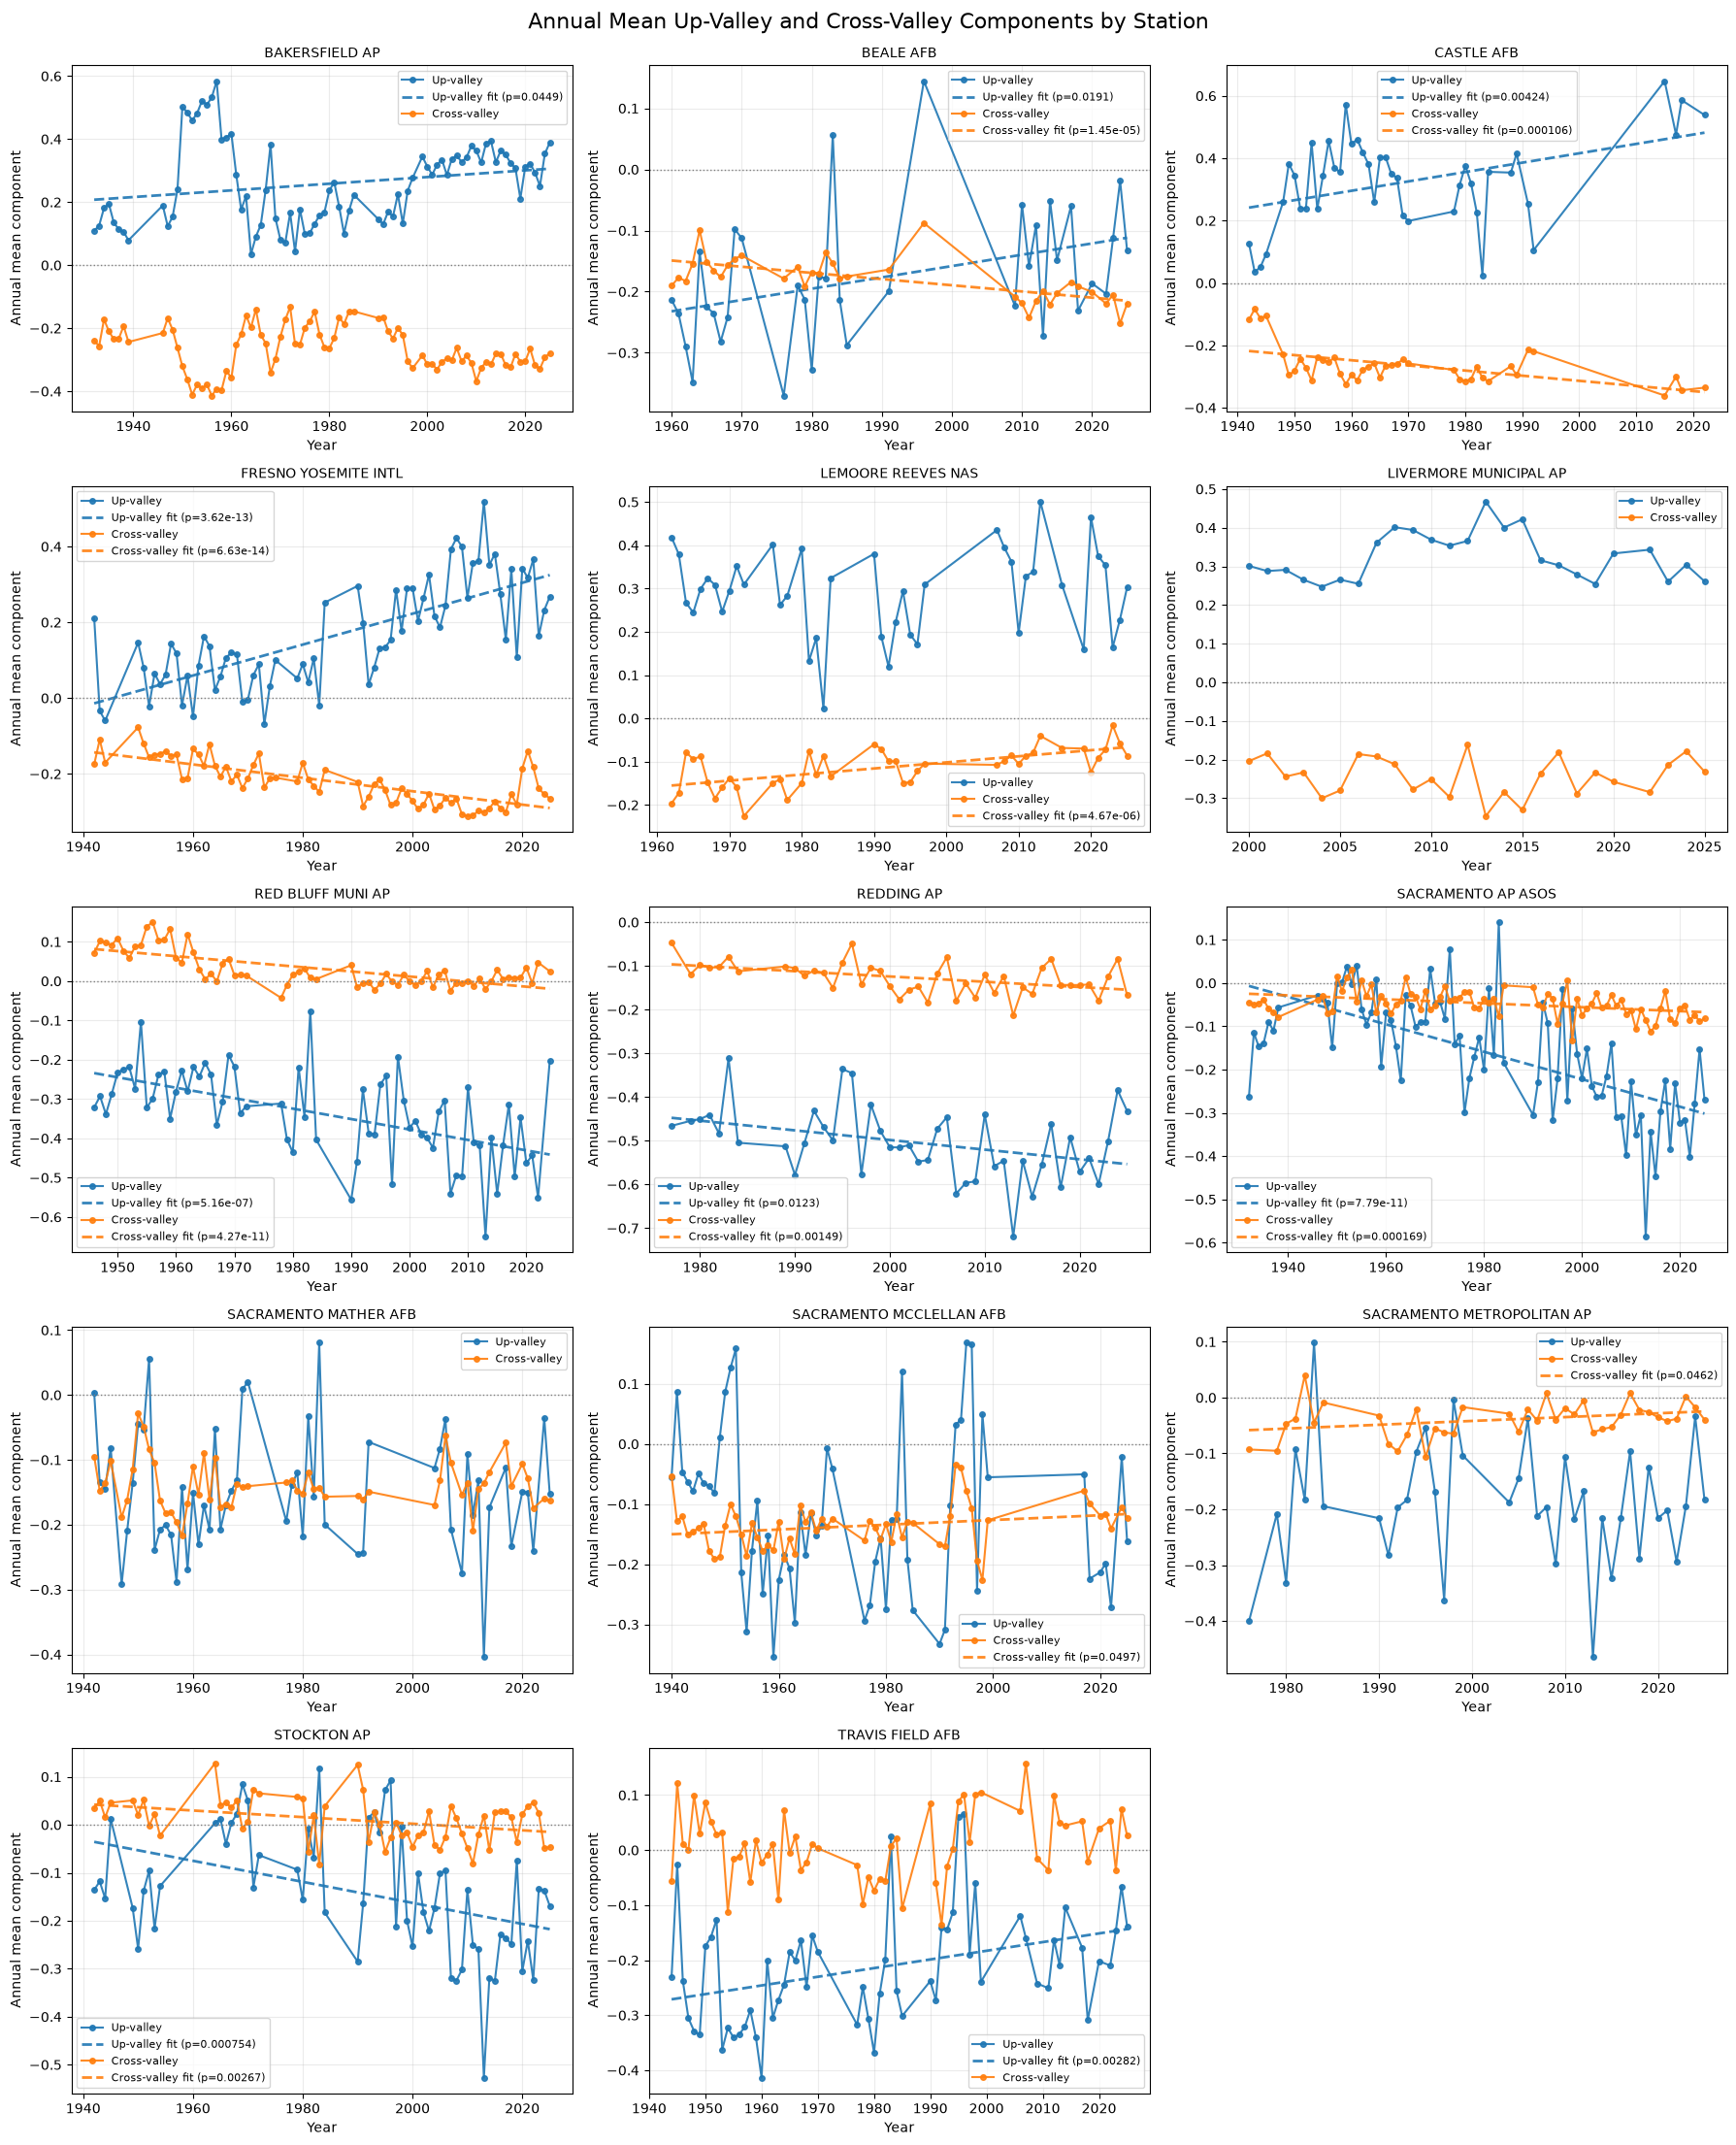

In [14]:
# Trend analysis of annual mean up-valley and cross-valley components by station
# Only plot regression lines for statistically significant trends (p < 0.05)

trend_rows = []

for station, g in annual_avg_wind.groupby("STATION"):
    for component, value_col in [
        ("up_valley", "mean_up_valley_component"),
        ("cross_valley", "mean_cross_valley_component"),
    ]:
        d = g[["year", value_col]].dropna()

        if d.empty or d["year"].nunique() < 3 or d[value_col].nunique() < 2:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d[value_col].to_numpy())

        trend_rows.append({
            "STATION": station,
            "component": component,
            "start_year": int(d["year"].min()),
            "end_year": int(d["year"].max()),
            "n_years": int(d["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

trend_df = pd.DataFrame(trend_rows).sort_values(["STATION", "component"]).reset_index(drop=True)
sig_trends = trend_df[trend_df["p_value"] < 0.05].copy()

print(f"Total station-component regressions: {len(trend_df)}")
print(f"Significant trends (p < 0.05): {len(sig_trends)}")
display(sig_trends.sort_values(["component", "p_value"]).reset_index(drop=True))

stations = sorted(annual_avg_wind["STATION"].unique())
ncols = 3
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows), squeeze=False)
axes = axes.ravel()

for ax, station in zip(axes, stations):
    d = annual_avg_wind[annual_avg_wind["STATION"] == station].sort_values("year")

    for component, value_col, color, label in [
        ("up_valley", "mean_up_valley_component", "tab:blue", "Up-valley"),
        ("cross_valley", "mean_cross_valley_component", "tab:orange", "Cross-valley"),
    ]:
        ax.plot(
            d["year"],
            d[value_col],
            marker="o",
            markersize=4,
            linewidth=1.5,
            color=color,
            label=label,
            alpha=0.9,
        )

        result = trend_df[
            (trend_df["STATION"] == station) &
            (trend_df["component"] == component)
        ]

        if not result.empty and result.iloc[0]["p_value"] < 0.05:
            fit = result.iloc[0]
            fitted = fit["intercept"] + fit["slope_per_year"] * d["year"]
            ax.plot(
                d["year"],
                fitted,
                color=color,
                linestyle="--",
                linewidth=2,
                alpha=0.9,
                label=f"{label} fit (p={fit['p_value']:.3g})"
            )

    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual mean component")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")

for ax in axes[len(stations):]:
    ax.remove()

fig.suptitle("Annual Mean Up-Valley and Cross-Valley Components by Station\n", fontsize=16)
plt.tight_layout()
plt.show()

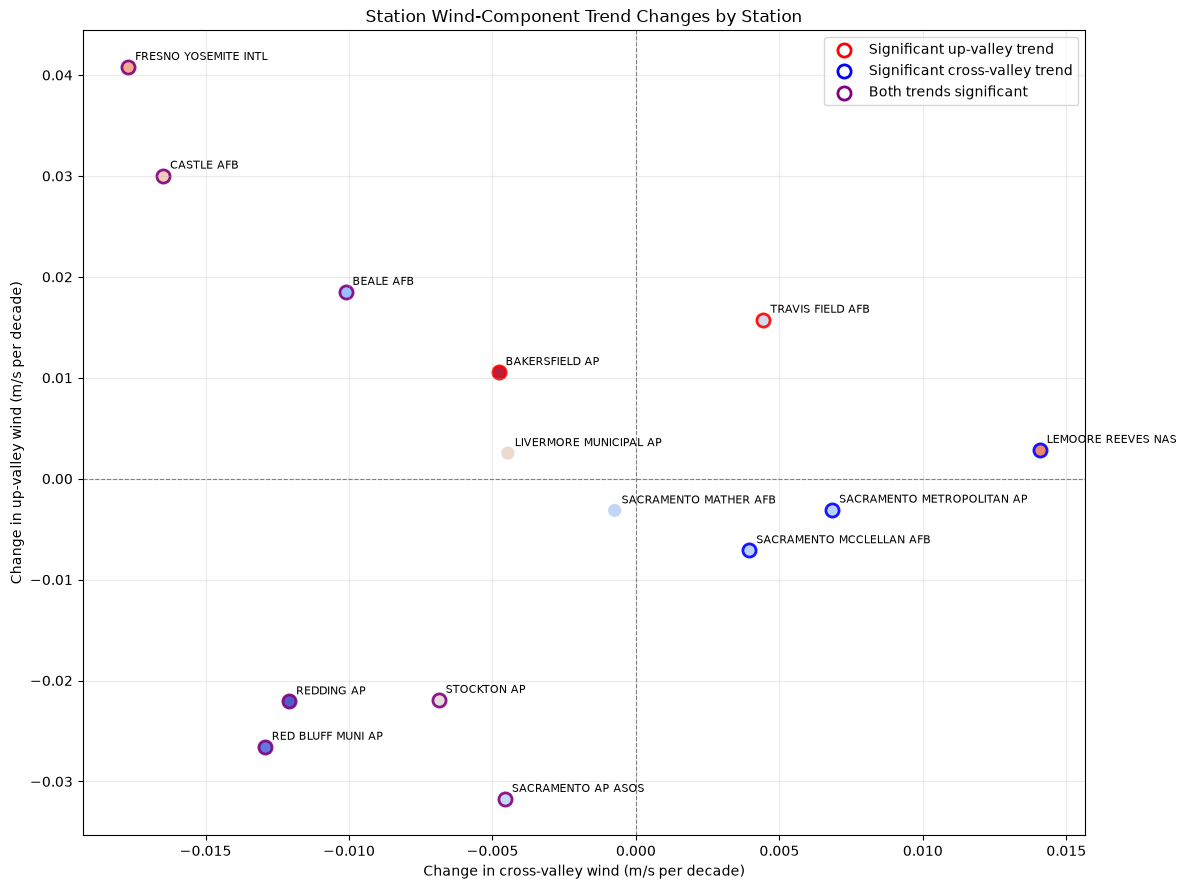

In [15]:
# Plot each station's change in up-valley wind vs. change in cross-valley wind
# Red outline = significant up-valley trend
# Blue outline = significant cross-valley trend
# Purple outline = both significant

slope_data = (
    trend_df
    .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
    .dropna()
)

slope_data.columns = [
    f"{metric}_{component}"
    for metric, component in slope_data.columns
]

plot_data = (
    slope_data
    .reset_index()
    .merge(station_lat, on="STATION", how="left")
    .dropna(subset=["latitude"])
)

lat_min = plot_data["latitude"].min()
lat_max = plot_data["latitude"].max()
lat_range = lat_max - lat_min if lat_max != lat_min else 1

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_data.iterrows():
    station = row["STATION"]
    x = row["slope_per_decade_cross_valley"]
    y = row["slope_per_decade_up_valley"]

    sig_up = row["p_value_up_valley"] < 0.05
    sig_cross = row["p_value_cross_valley"] < 0.05

    if sig_up and sig_cross:
        outline_color = "purple"
    elif sig_up:
        outline_color = "red"
    elif sig_cross:
        outline_color = "blue"
    else:
        outline_color = "none"

    point_color = plt.cm.coolwarm_r((row["latitude"] - lat_min) / lat_range)

    ax.scatter(
        x,
        y,
        color=point_color,
        edgecolors=outline_color,
        linewidths=2 if outline_color != "none" else 0.8,
        s=90,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [],
        color="white",
        edgecolors=color,
        linewidths=2,
        s=90,
        label=label,
    )

ax.set_xlabel("Change in cross-valley wind (m/s per decade)")
ax.set_ylabel("Change in up-valley wind (m/s per decade)")
ax.set_title("Station Wind-Component Trend Changes by Station")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

Total station-component regressions: 28
Significant trends (p < 0.05): 13


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,intercept,r_squared,p_value
0,BAKERSFIELD AP,cross_valley,1980,2025,41,-0.002977,-0.029775,5.694503,0.474883,6.299035e-07
1,BEALE AFB,cross_valley,1980,2025,22,-0.001550,-0.015505,2.917542,0.477264,3.714064e-04
2,SACRAMENTO AP ASOS,cross_valley,1980,2025,41,-0.001020,-0.010200,1.985659,0.191180,4.255444e-03
3,LEMOORE REEVES NAS,cross_valley,1980,2025,28,0.001091,0.010911,-2.279534,0.252199,6.465756e-03
4,REDDING AP,cross_valley,1980,2025,42,-0.001091,-0.010908,2.056181,0.168383,6.952808e-03
5,TRAVIS FIELD AFB,cross_valley,1980,2025,30,0.001753,0.017534,-3.491146,0.132203,4.826023e-02
6,BAKERSFIELD AP,up_valley,1980,2025,41,0.004137,0.041375,-8.010273,0.461176,1.055057e-06
7,SACRAMENTO AP ASOS,up_valley,1980,2025,41,-0.005791,-0.057906,11.367941,0.329827,8.623748e-05
8,FRESNO YOSEMITE INTL,up_valley,1980,2025,41,0.005116,0.051165,-10.011659,0.309713,1.577917e-04
9,STOCKTON AP,up_valley,1980,2025,41,-0.005343,-0.053431,10.539937,0.261320,6.364901e-04


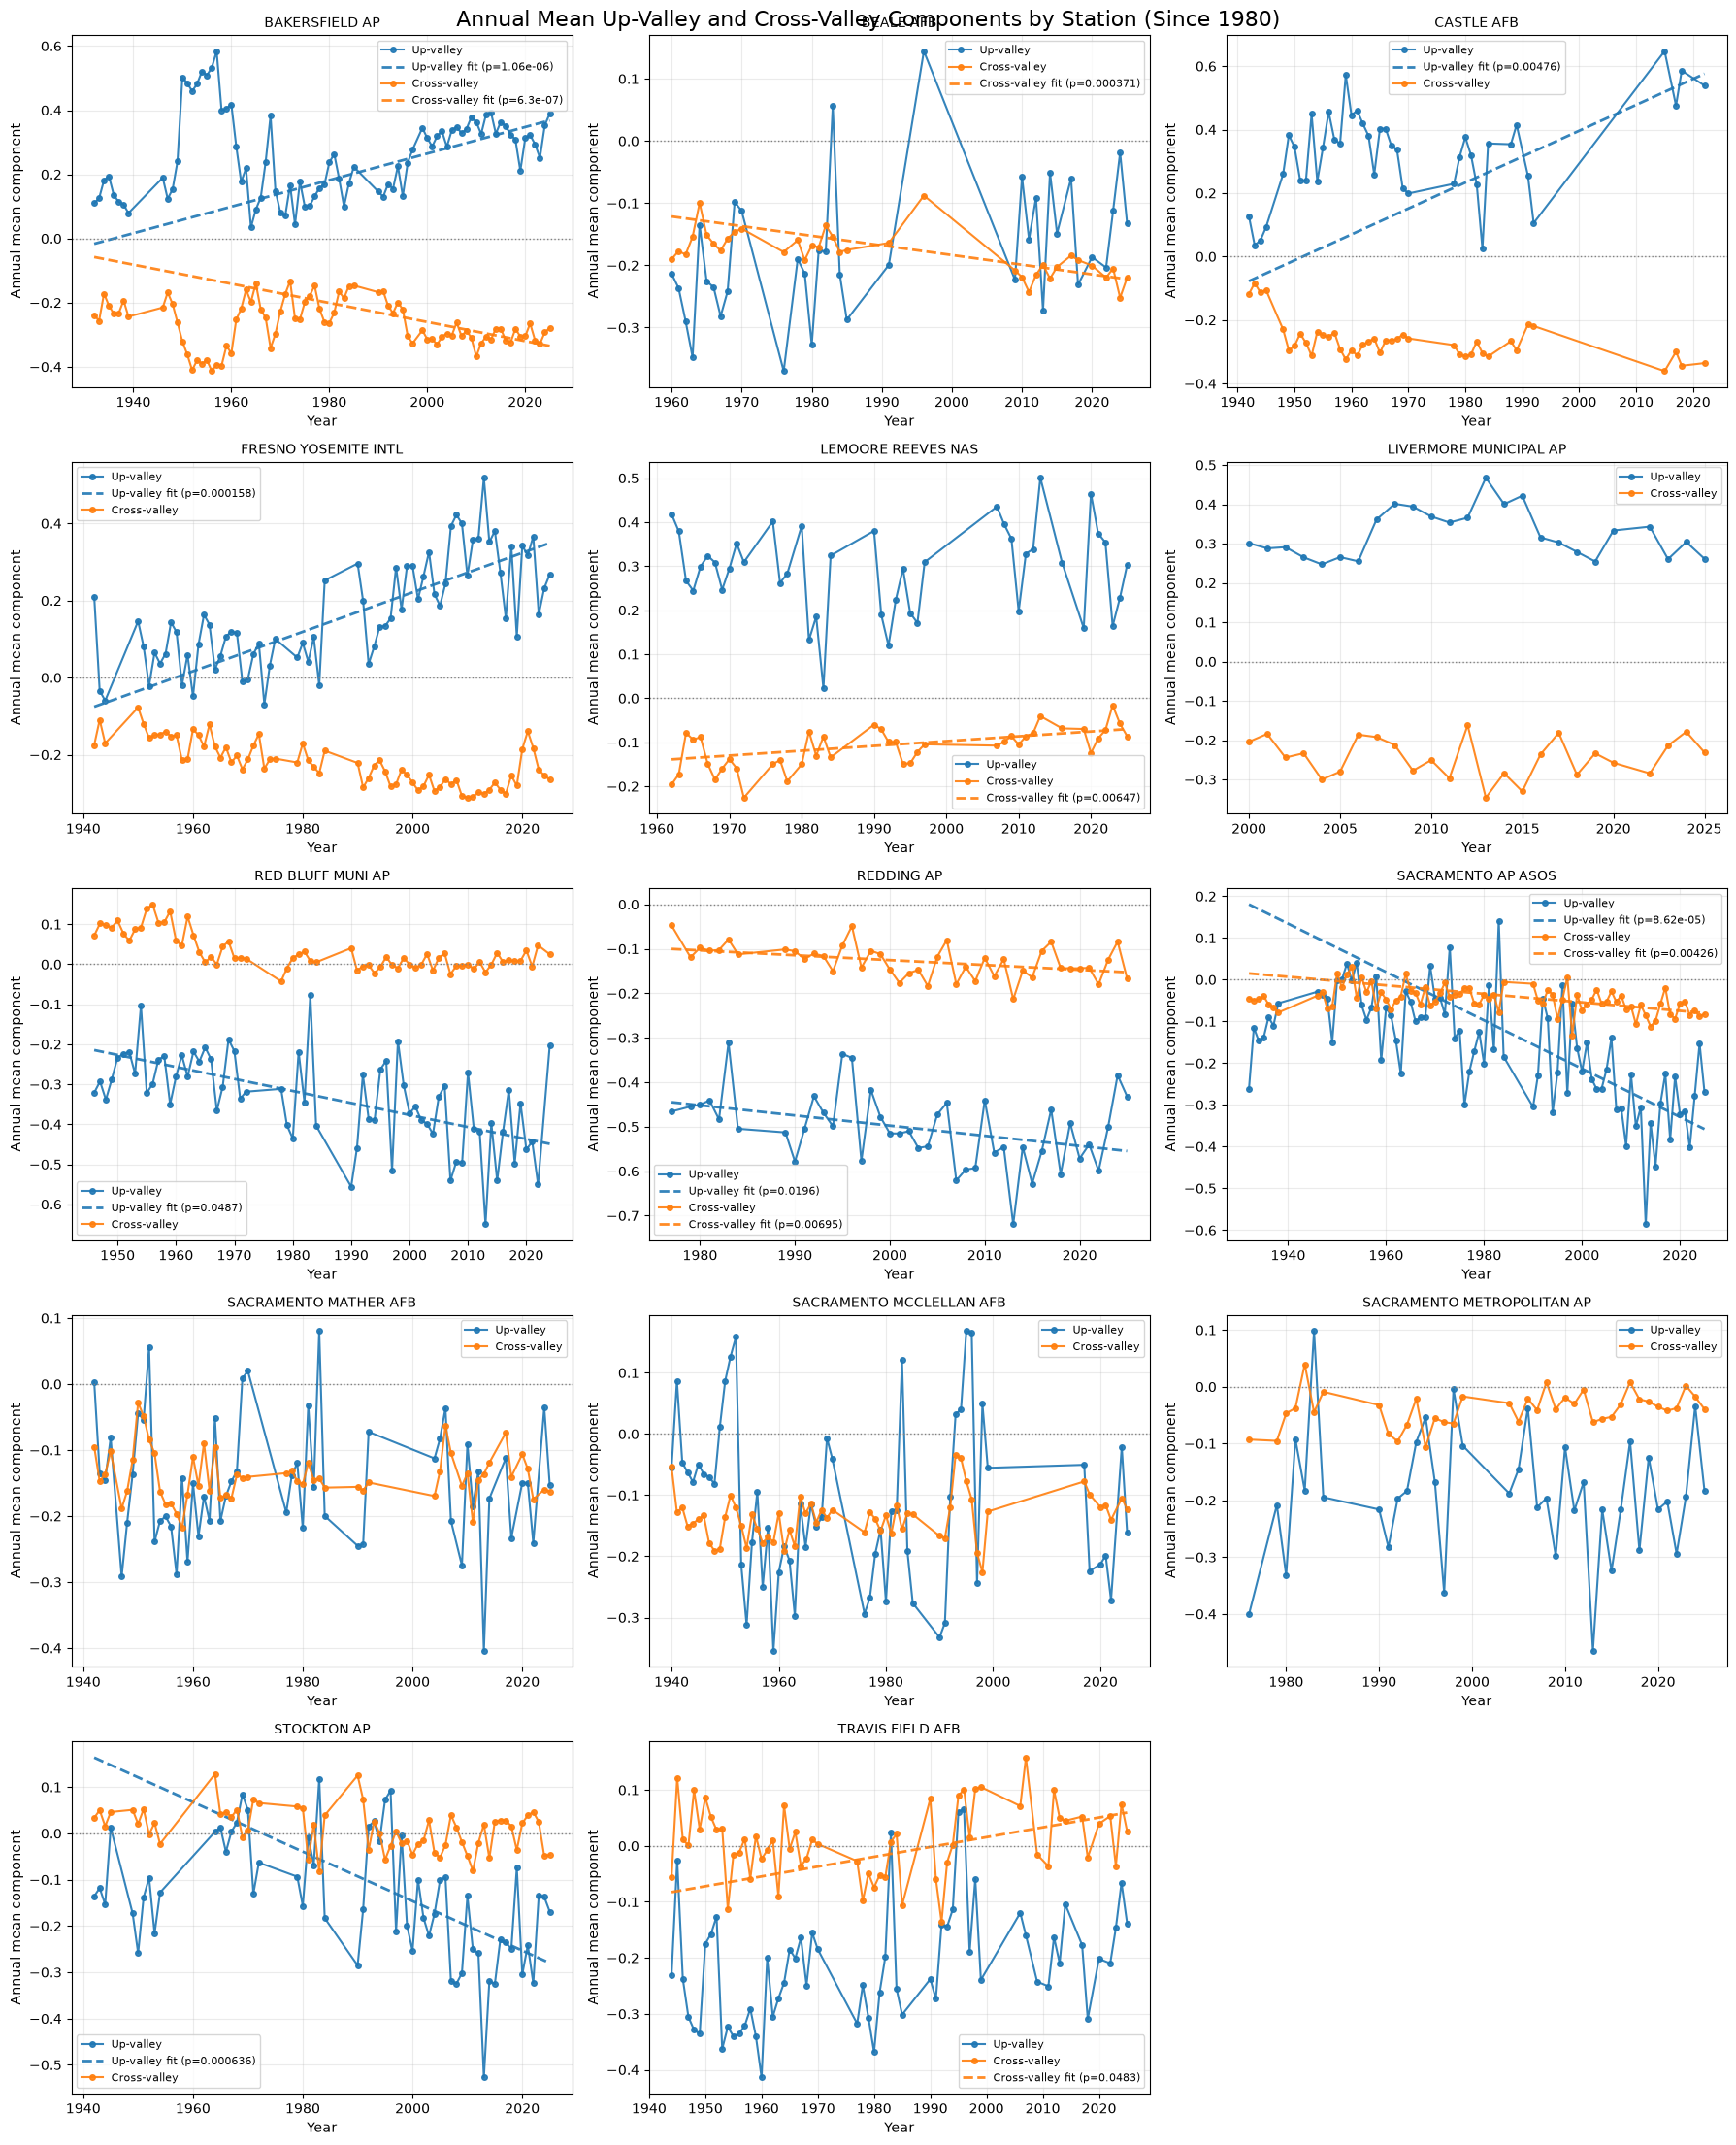

In [16]:
# Trend analysis of annual mean up-valley and cross-valley components by station
# Only use years since 1980
# Only plot regression lines for statistically significant trends (p < 0.05)

trend_rows_1980 = []

for station, g in annual_avg_wind[annual_avg_wind["year"] >= 1980].groupby("STATION"):
    for component, value_col in [
        ("up_valley", "mean_up_valley_component"),
        ("cross_valley", "mean_cross_valley_component"),
    ]:
        d = g[["year", value_col]].dropna()

        if d.empty or d["year"].nunique() < 3 or d[value_col].nunique() < 2:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d[value_col].to_numpy())

        trend_rows_1980.append({
            "STATION": station,
            "component": component,
            "start_year": int(d["year"].min()),
            "end_year": int(d["year"].max()),
            "n_years": int(d["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

trend_df_1980 = pd.DataFrame(trend_rows_1980).sort_values(["STATION", "component"]).reset_index(drop=True)
sig_trends = trend_df_1980[trend_df_1980["p_value"] < 0.05].copy()

print(f"Total station-component regressions: {len(trend_df_1980)}")
print(f"Significant trends (p < 0.05): {len(sig_trends)}")
display(sig_trends.sort_values(["component", "p_value"]).reset_index(drop=True))

stations = sorted(annual_avg_wind["STATION"].unique())
ncols = 3
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows), squeeze=False)
axes = axes.ravel()

for ax, station in zip(axes, stations):
    d = annual_avg_wind[annual_avg_wind["STATION"] == station].sort_values("year")

    for component, value_col, color, label in [
        ("up_valley", "mean_up_valley_component", "tab:blue", "Up-valley"),
        ("cross_valley", "mean_cross_valley_component", "tab:orange", "Cross-valley"),
    ]:
        ax.plot(
            d["year"],
            d[value_col],
            marker="o",
            markersize=4,
            linewidth=1.5,
            color=color,
            label=label,
            alpha=0.9,
        )

        result = trend_df_1980[
            (trend_df_1980["STATION"] == station) &
            (trend_df_1980["component"] == component)
        ]

        if not result.empty and result.iloc[0]["p_value"] < 0.05:
            fit = result.iloc[0]
            fitted = fit["intercept"] + fit["slope_per_year"] * d["year"]
            ax.plot(
                d["year"],
                fitted,
                color=color,
                linestyle="--",
                linewidth=2,
                alpha=0.9,
                label=f"{label} fit (p={fit['p_value']:.3g})"
            )

    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual mean component")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")

for ax in axes[len(stations):]:
    ax.remove()

fig.suptitle("Annual Mean Up-Valley and Cross-Valley Components by Station (Since 1980)", fontsize=16)
plt.tight_layout()
plt.show()

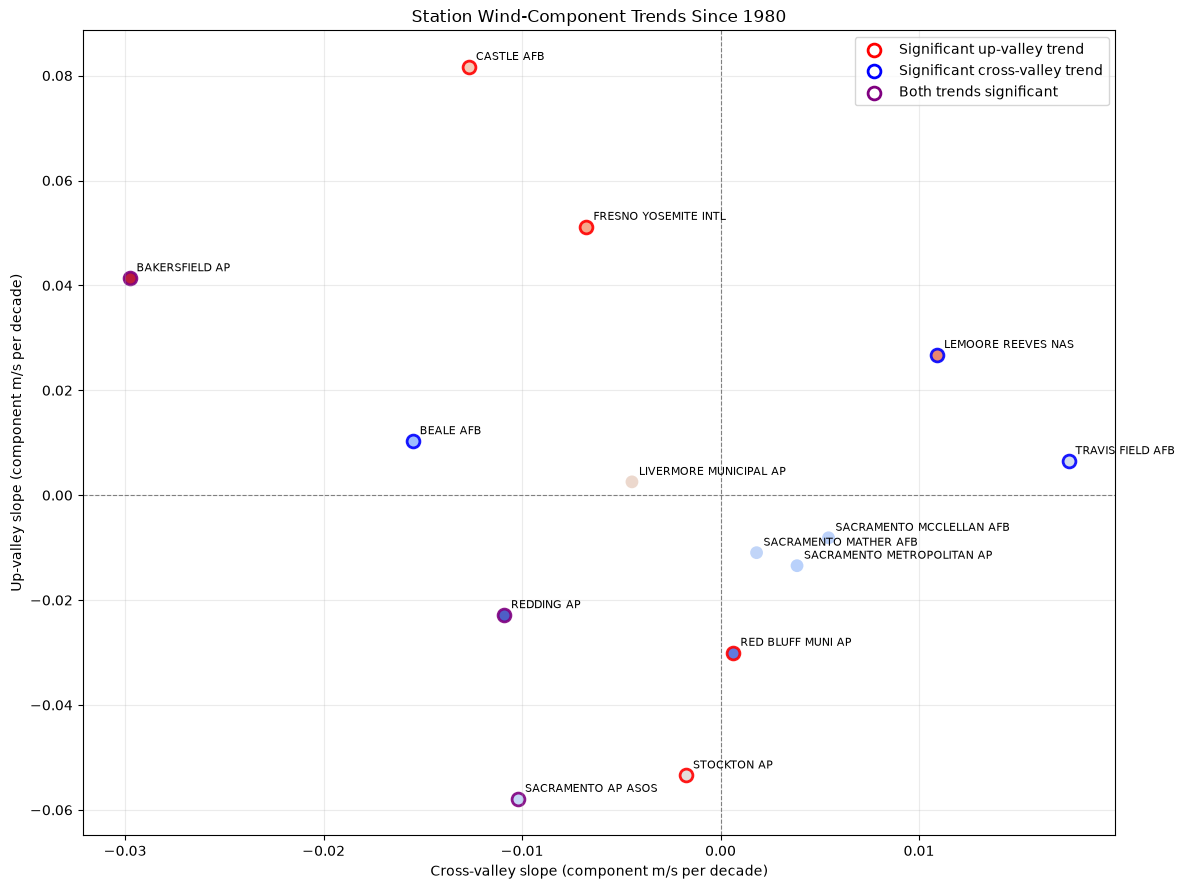

In [17]:
# Plot 1980 onward station trends with significance shown by outline color:
# red = significant up-valley trend
# blue = significant cross-valley trend
# purple = both significant

slope_data_1980 = (
    trend_df_1980
    .pivot(index="STATION", columns="component", values=["slope_per_decade", "p_value"])
    .dropna()
)

slope_data_1980.columns = [
    f"{metric}_{component}"
    for metric, component in slope_data_1980.columns
]

plot_data_1980 = (
    slope_data_1980
    .reset_index()
    .merge(station_lat, on="STATION", how="left")
    .dropna(subset=["latitude"])
)

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_data_1980.iterrows():
    station = row["STATION"]
    color = plt.cm.coolwarm_r((row["latitude"] - lat_min) / lat_range)

    significant_up = row["p_value_up_valley"] < 0.05
    significant_cross = row["p_value_cross_valley"] < 0.05

    if significant_up and significant_cross:
        outline_color = "purple"
    elif significant_up:
        outline_color = "red"
    elif significant_cross:
        outline_color = "blue"
    else:
        outline_color = "none"

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        color=color,
        marker="o",
        s=85,
        edgecolors=outline_color,
        linewidths=2 if outline_color != "none" else 0.8,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

# Significance legend
for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [], color="white", edgecolors=color, marker="o",
        s=85, linewidths=2, label=label
    )

ax.set_xlabel("Cross-valley slope (component m/s per decade)")
ax.set_ylabel("Up-valley slope (component m/s per decade)")
ax.set_title("Station Wind-Component Trends Since 1980")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [18]:
# Identify individual fog events as consecutive hourly fog observations (HourlyVisibility < 1)
fog_rows = CV_filtered_rows[CV_filtered_rows["HourlyVisibility"] < 1].copy()

# Construct timestamps from year, month, day, and hour
fog_rows["timestamp"] = (
    pd.to_datetime(fog_rows[["year", "month", "day"]])
    + pd.to_timedelta(fog_rows["hour"], unit="h")
)

fog_rows = fog_rows.dropna(subset=["timestamp"]).sort_values(["STATION", "timestamp"])

# Consecutive hourly observations belong to the same event
time_gap = fog_rows.groupby("STATION")["timestamp"].diff()
fog_rows["new_event"] = time_gap.isna() | (time_gap > pd.Timedelta(hours=1))
fog_rows["event_number"] = fog_rows.groupby("STATION")["new_event"].cumsum().astype(int)

# Aggregate events and calculate mean wind-direction components
fog_events = (
    fog_rows
    .groupby(["STATION", "event_number"], as_index=False)
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        n_observations=("timestamp", "size"),
        min_visibility=("HourlyVisibility", "min"),
        mean_visibility=("HourlyVisibility", "mean"),
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        up_valley_direction=("up_valley_direction", "first"),
        cross_valley_direction=("cross_valley_direction", "first"),
    )
)

# Calculate duration in hours
fog_events["duration_hours"] = (
    (fog_events["end_time"] - fog_events["start_time"]).dt.total_seconds() / 3600 + 1
)

# Calculate average wind direction from mean components for each event
fog_events["avg_wind_direction_deg"] = np.mod(
    np.rad2deg(
        np.arctan2(
            fog_events["mean_cross_valley_component"],
            fog_events["mean_up_valley_component"]
        )
    ) + fog_events["up_valley_direction"],
    360.0
)

fog_events = fog_events.sort_values(["STATION", "start_time"]).reset_index(drop=True)

print(f"Total fog events: {len(fog_events)}")
display(fog_events.head(10))

Total fog events: 28270


,STATION,event_number,start_time,end_time,n_observations,min_visibility,mean_visibility,mean_up_valley_component,mean_cross_valley_component,up_valley_direction,cross_valley_direction,duration_hours,avg_wind_direction_deg
0,BAKERSFIELD AP,1,1932-01-01 07:00:00,1932-01-01 08:00:00,2,0.0,0.000000,-0.579228,0.405580,145.0,55.0,2.0,290.000000
1,BAKERSFIELD AP,2,1932-01-04 08:00:00,1932-01-04 08:00:00,1,0.0,0.000000,-0.984808,-0.173648,145.0,55.0,1.0,335.000000
2,BAKERSFIELD AP,3,1932-01-08 17:00:00,1932-01-08 18:00:00,2,0.0,0.000000,0.984808,0.173648,145.0,55.0,2.0,155.000000
3,BAKERSFIELD AP,4,1932-01-09 03:00:00,1932-01-09 08:00:00,6,0.0,0.366667,-0.121873,-0.549735,145.0,55.0,6.0,42.500000
4,BAKERSFIELD AP,5,1932-01-09 18:00:00,1932-01-09 18:00:00,1,0.0,0.000000,0.984808,0.173648,145.0,55.0,1.0,155.000000
5,BAKERSFIELD AP,6,1932-01-09 20:00:00,1932-01-10 07:00:00,12,0.0,0.283333,0.462521,0.455081,145.0,55.0,12.0,189.535456
6,BAKERSFIELD AP,7,1932-01-19 02:00:00,1932-01-19 03:00:00,2,0.2,0.500000,-0.779192,-0.496400,145.0,55.0,2.0,357.500000
7,BAKERSFIELD AP,8,1932-01-20 08:00:00,1932-01-20 08:00:00,1,0.8,0.800000,-0.984808,-0.173648,145.0,55.0,1.0,335.000000
8,BAKERSFIELD AP,9,1932-01-23 07:00:00,1932-01-23 08:00:00,2,0.0,0.000000,-0.286788,-0.409576,145.0,55.0,2.0,20.000000
9,BAKERSFIELD AP,10,1932-01-27 08:00:00,1932-01-27 08:00:00,1,0.2,0.200000,0.984808,0.173648,145.0,55.0,1.0,155.000000


,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,r_squared,p_value,significant
17,SACRAMENTO AP ASOS,cross_valley,1932,2025,82,-0.002033,-0.020327,0.346216,6.127053e-09,True
7,FRESNO YOSEMITE INTL,cross_valley,1942,2025,71,-0.002928,-0.029276,0.240587,1.410033e-05,True
5,CASTLE AFB,cross_valley,1942,2022,42,-0.002935,-0.029353,0.252834,6.894540e-04,True
21,SACRAMENTO MCCLELLAN AFB,cross_valley,1940,2025,58,-0.001595,-0.015954,0.158329,1.980025e-03,True
19,SACRAMENTO MATHER AFB,cross_valley,1942,2025,56,-0.001186,-0.011860,0.085855,2.841018e-02,True
1,BAKERSFIELD AP,cross_valley,1932,2025,83,-0.001498,-0.014976,0.049446,4.333199e-02,True
23,SACRAMENTO METROPOLITAN AP,cross_valley,1976,2025,39,0.002228,0.022280,0.097095,5.348156e-02,False
13,RED BLUFF MUNI AP,cross_valley,1946,2024,68,-0.001148,-0.011479,0.038793,1.074266e-01,False
9,LEMOORE REEVES NAS,cross_valley,1962,2025,42,0.000804,0.008038,0.046198,1.716380e-01,False
27,TRAVIS FIELD AFB,cross_valley,1944,2025,60,0.001068,0.010678,0.025156,2.261248e-01,False


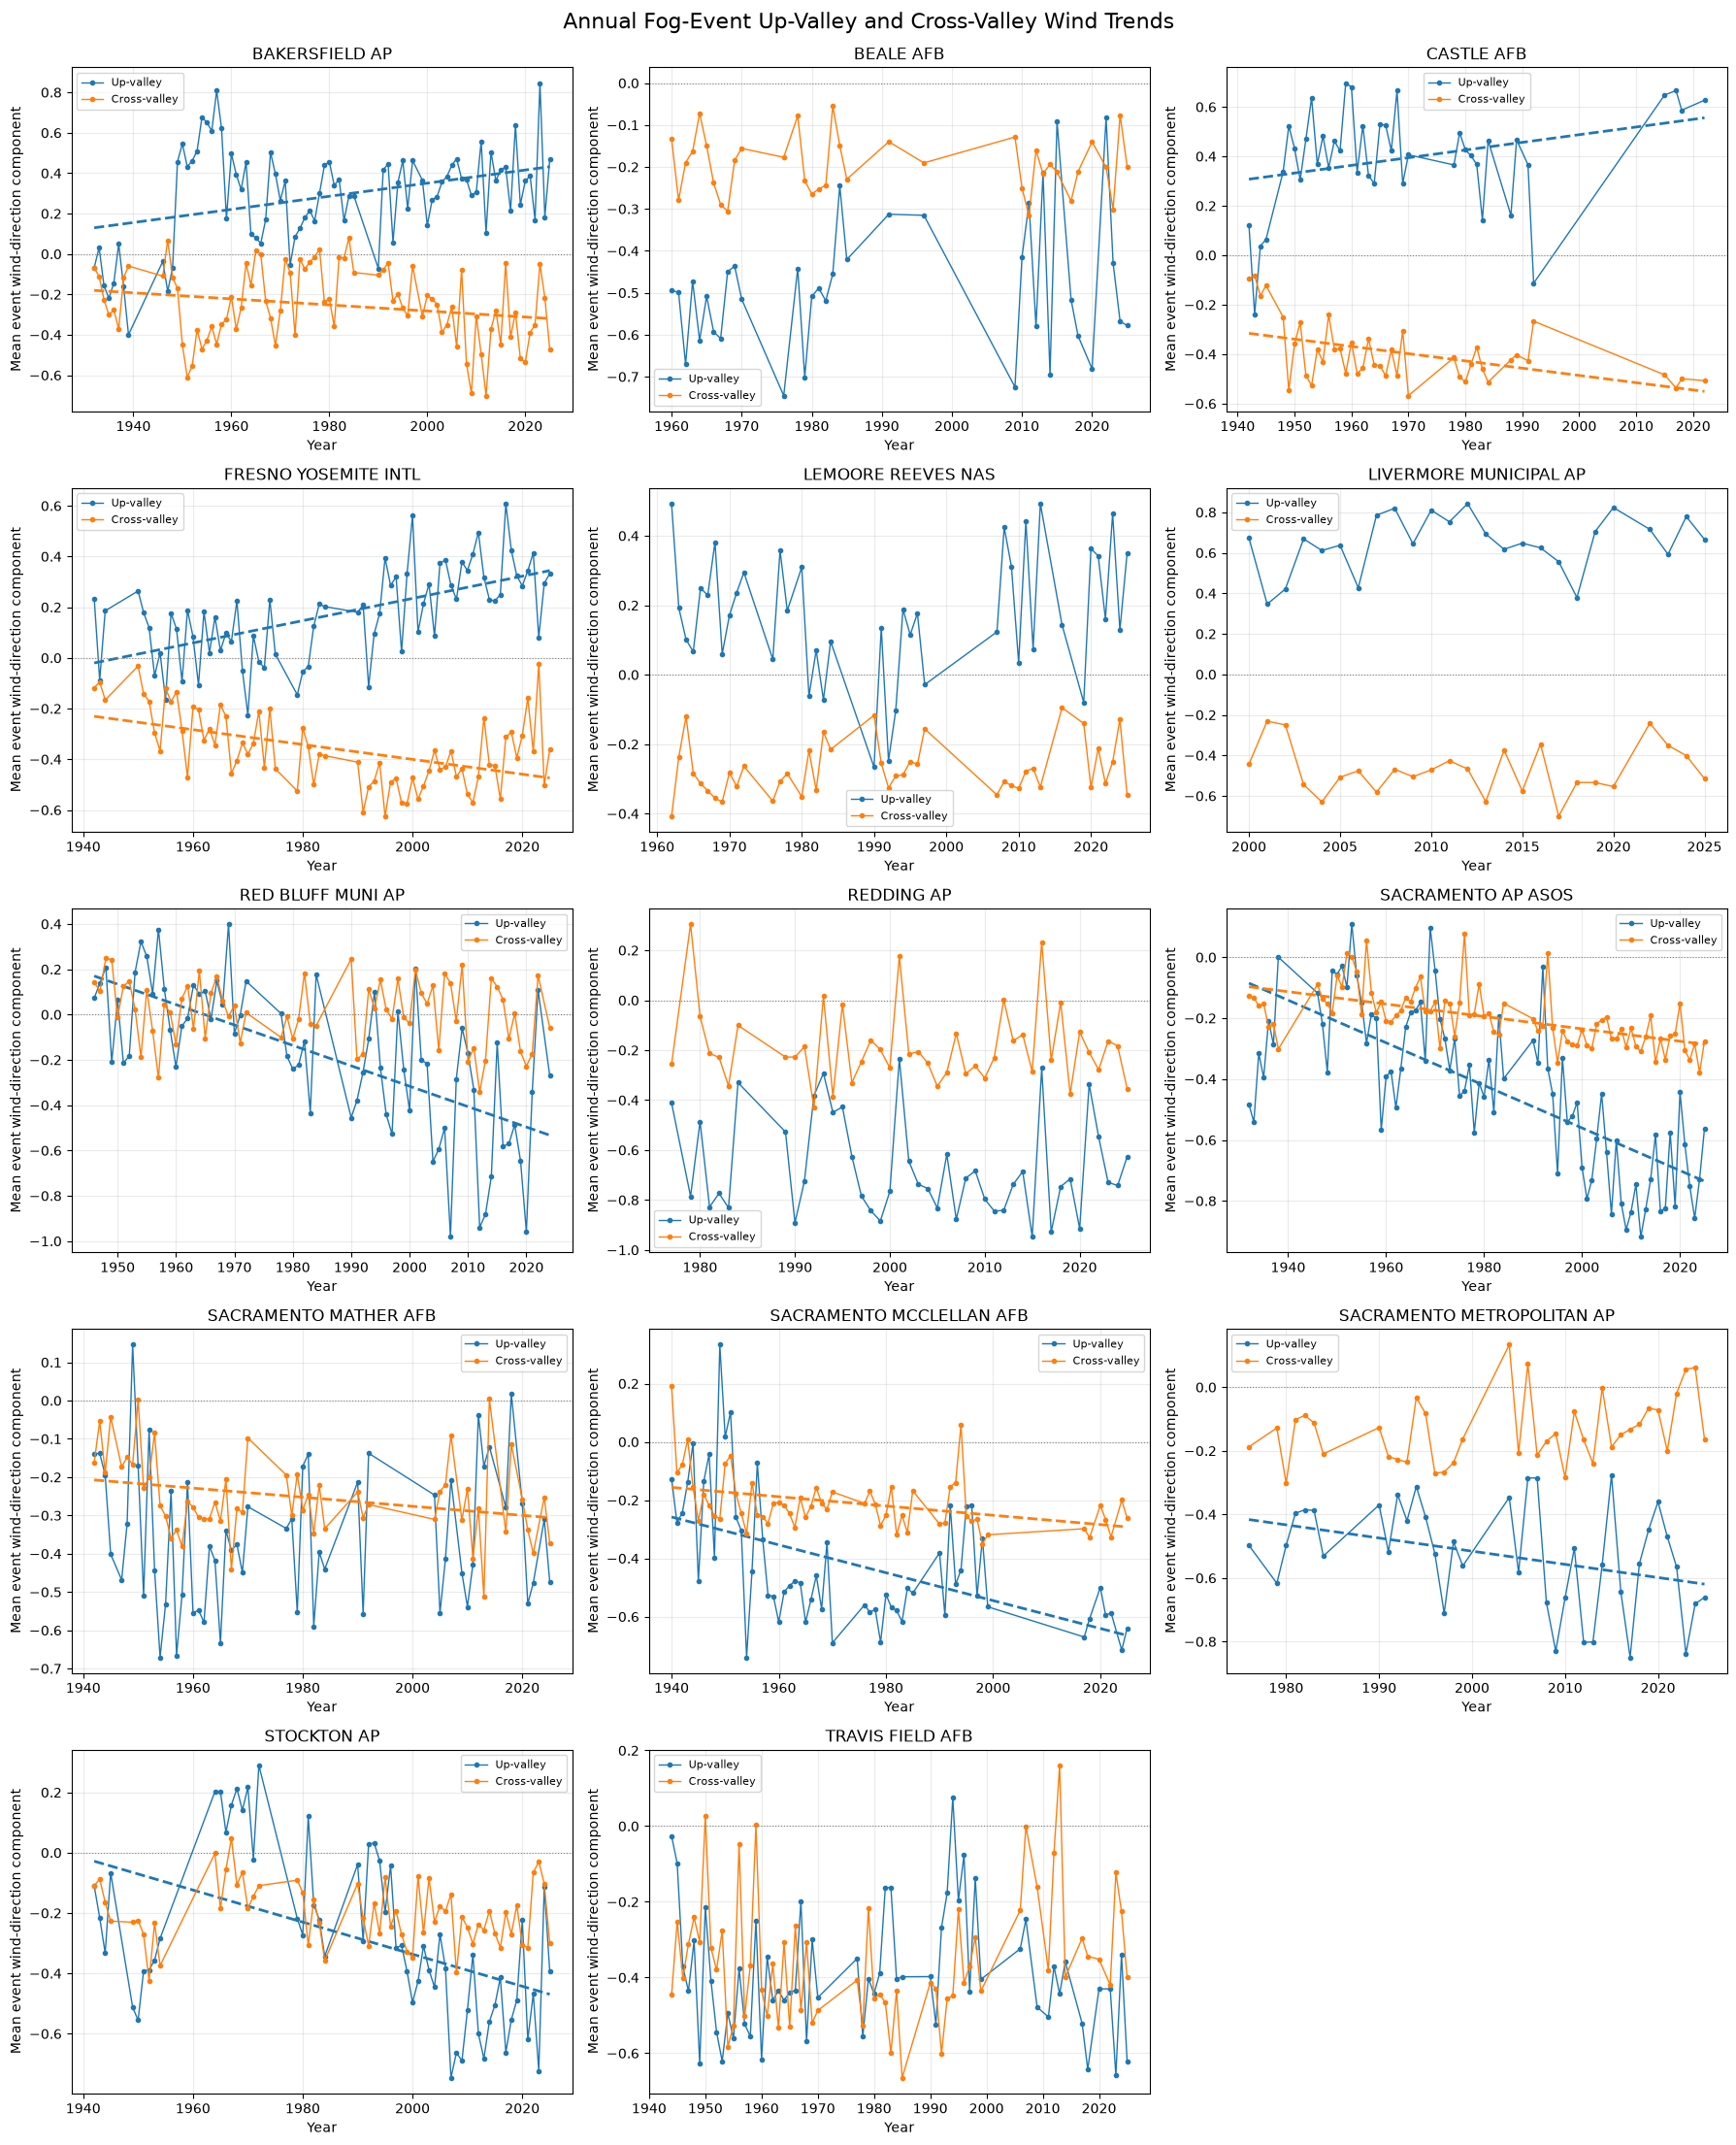

In [19]:
# Annual fog-event wind-direction trends by station.
# Regression lines are shown only when p < 0.05.

# Use the event observations created in cell 23
event_obs = fog_rows[
    [
        "STATION", "event_number", "year", "HourlyWindDirection",
        "up_valley_direction", "cross_valley_direction"
    ]
].copy()

event_obs["HourlyWindDirection"] = pd.to_numeric(
    event_obs["HourlyWindDirection"], errors="coerce"
)
event_obs = event_obs.dropna(subset=["HourlyWindDirection", "year"])

# Calculate circular mean wind direction for each fog event
event_obs["wind_rad"] = np.deg2rad(event_obs["HourlyWindDirection"])
event_obs["u"] = np.cos(event_obs["wind_rad"])
event_obs["v"] = np.sin(event_obs["wind_rad"])

event_wind = (
    event_obs
    .groupby(["STATION", "event_number"], as_index=False)
    .agg(
        year=("year", "first"),
        mean_u=("u", "mean"),
        mean_v=("v", "mean"),
        up_valley_direction=("up_valley_direction", "first"),
        cross_valley_direction=("cross_valley_direction", "first"),
        n_observations=("HourlyWindDirection", "size"),
    )
)

event_wind["event_mean_direction"] = np.mod(
    np.rad2deg(np.arctan2(event_wind["mean_v"], event_wind["mean_u"])),
    360
)

# Calculate event-level alignment with each local axis
# multiply by the wind speed for each event to get the actual wind component along the up-valley direction
event_wind["up_valley_component"] = np.cos(
    np.deg2rad(
        event_wind["event_mean_direction"]
        - event_wind["up_valley_direction"]
    )
)    
# ) * event_wind["n_observations"]

event_wind["cross_valley_component"] = np.cos(
    np.deg2rad(
        event_wind["event_mean_direction"]
        - event_wind["cross_valley_direction"]
    )
) 
# ) * event_wind["n_observations"]

# Annual averages of fog-event directional components
annual_event_wind = (
    event_wind
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_events=("event_number", "size"),
    )
    .sort_values(["STATION", "year"])
)

# Fit trends for each station and component
event_trend_rows = []

for station, group in annual_event_wind.groupby("STATION"):
    for component, column in [
        ("up_valley", "mean_up_valley_component"),
        ("cross_valley", "mean_cross_valley_component"),
    ]:
        data = group[["year", column]].dropna()

        if data["year"].nunique() < 3 or data[column].nunique() < 2:
            continue

        fit = stats.linregress(data["year"], data[column])

        event_trend_rows.append({
            "STATION": station,
            "component": component,
            "start_year": int(data["year"].min()),
            "end_year": int(data["year"].max()),
            "n_years": int(data["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

event_trends = pd.DataFrame(event_trend_rows)
event_trends["significant"] = event_trends["p_value"] < 0.05

display(event_trends.sort_values(["component", "p_value"]))

# Plot both components for every station
stations = sorted(annual_event_wind["STATION"].unique())
ncols = 3
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(18, 4.5 * nrows),
    squeeze=False
)
axes = axes.ravel()

for ax, station in zip(axes, stations):
    data = annual_event_wind[
        annual_event_wind["STATION"] == station
    ].sort_values("year")

    for component, column, color, label in [
        (
            "up_valley",
            "mean_up_valley_component",
            "tab:blue",
            "Up-valley",
        ),
        (
            "cross_valley",
            "mean_cross_valley_component",
            "tab:orange",
            "Cross-valley",
        ),
    ]:
        ax.plot(
            data["year"],
            data[column],
            marker="o",
            markersize=3,
            linewidth=1,
            color=color,
            label=label,
        )

        result = event_trends[
            (event_trends["STATION"] == station)
            & (event_trends["component"] == component)
        ]

        # Add a regression line only for significant trends
        if not result.empty and result.iloc[0]["significant"]:
            result = result.iloc[0]
            fitted = (
                result["slope_per_year"] * data["year"]
                + (
                    data[column].mean()
                    - result["slope_per_year"] * data["year"].mean()
                )
            )

            ax.plot(
                data["year"],
                fitted,
                color=color,
                linestyle="--",
                linewidth=2,
            )

    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean event wind-direction component")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

for ax in axes[len(stations):]:
    ax.remove()

fig.suptitle(
    "Annual Fog-Event Up-Valley and Cross-Valley Wind Trends\n",
    fontsize=16,
)
plt.tight_layout()
plt.show()

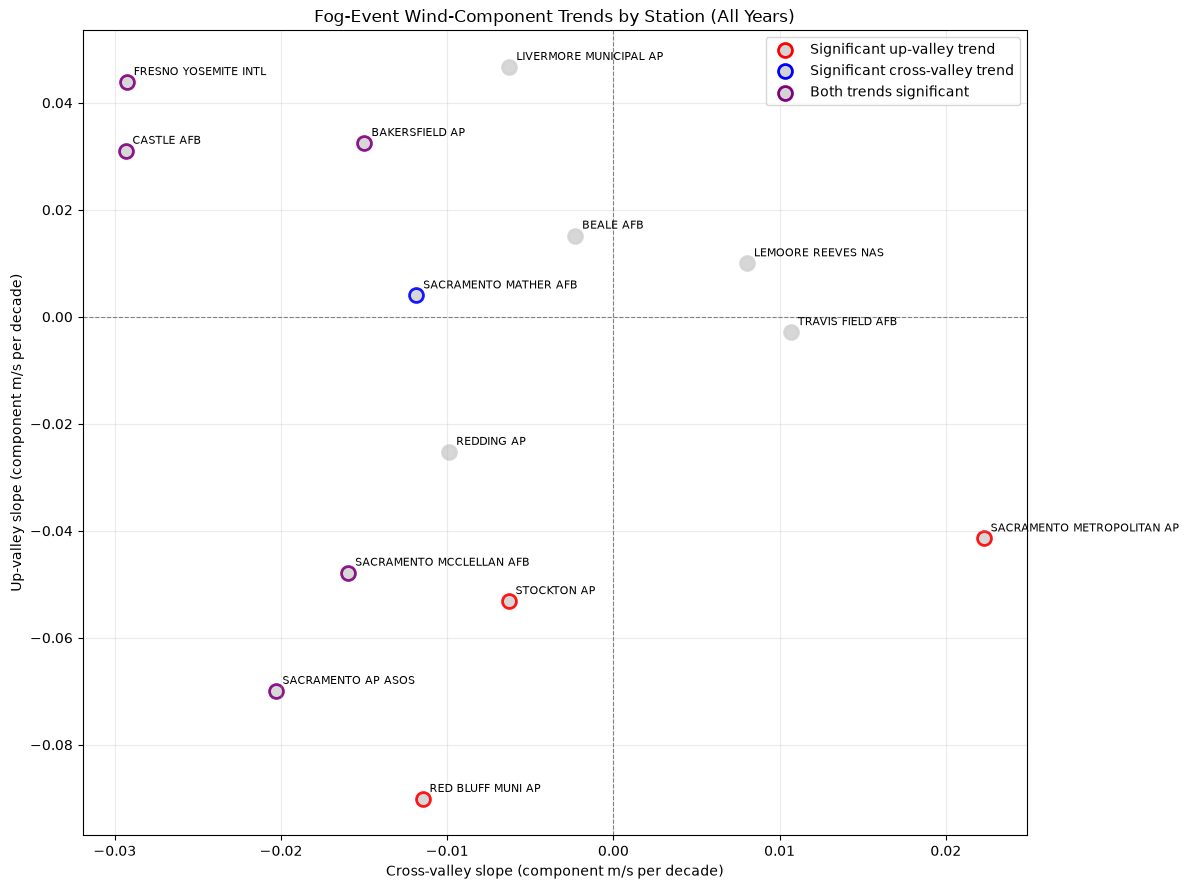

In [20]:
# Plot fog-event trend slopes:
# x-axis = cross-valley slope; y-axis = up-valley slope.
# Red outline = significant up-valley trend
# Blue outline = significant cross-valley trend
# Purple outline = both trends significant

fog_slope_data = (
    event_trends
    .pivot(index="STATION", columns="component",
           values=["slope_per_decade", "p_value"])
    .dropna()
)

fog_slope_data.columns = [
    f"{metric}_{component}"
    for metric, component in fog_slope_data.columns
]

fig, ax = plt.subplots(figsize=(12, 9))

for station, row in fog_slope_data.iterrows():
    significant_up = row["p_value_up_valley"] < 0.05
    significant_cross = row["p_value_cross_valley"] < 0.05

    if significant_up and significant_cross:
        outline_color = "purple"
    elif significant_up:
        outline_color = "red"
    elif significant_cross:
        outline_color = "blue"
    else:
        outline_color = "lightgray"

    point_color = "lightgray"

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        s=100,
        color=point_color,
        edgecolor=outline_color,
        linewidth=2,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [], s=100, facecolor="lightgray",
        edgecolor=color, linewidth=2, label=label
    )

ax.set_xlabel("Cross-valley slope (component m/s per decade)")
ax.set_ylabel("Up-valley slope (component m/s per decade)")
ax.set_title("Fog-Event Wind-Component Trends by Station (All Years)")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

,STATION,component,start_year,end_year,n_years,slope_per_year,slope_per_decade,r_squared,p_value,significant
1,BAKERSFIELD AP,cross_valley,1980,2025,41,-0.007248,-0.072484,0.265236,0.000570,True
27,TRAVIS FIELD AFB,cross_valley,1980,2025,30,0.006552,0.065524,0.287224,0.002270,True
17,SACRAMENTO AP ASOS,cross_valley,1980,2025,41,-0.002237,-0.022374,0.186696,0.004786,True
7,FRESNO YOSEMITE INTL,cross_valley,1980,2025,41,0.002979,0.029794,0.102124,0.041680,True
23,SACRAMENTO METROPOLITAN AP,cross_valley,1980,2025,37,0.002485,0.024847,0.100829,0.055480,False
5,CASTLE AFB,cross_valley,1980,2022,13,-0.001859,-0.018588,0.163688,0.170294,False
13,RED BLUFF MUNI AP,cross_valley,1980,2024,39,-0.002080,-0.020804,0.029975,0.291876,False
21,SACRAMENTO MCCLELLAN AFB,cross_valley,1980,2025,23,-0.001080,-0.010796,0.035690,0.387968,False
25,STOCKTON AP,cross_valley,1980,2025,41,0.000277,0.002766,0.001615,0.802974,False
19,SACRAMENTO MATHER AFB,cross_valley,1980,2025,25,-0.000331,-0.003312,0.002168,0.825098,False


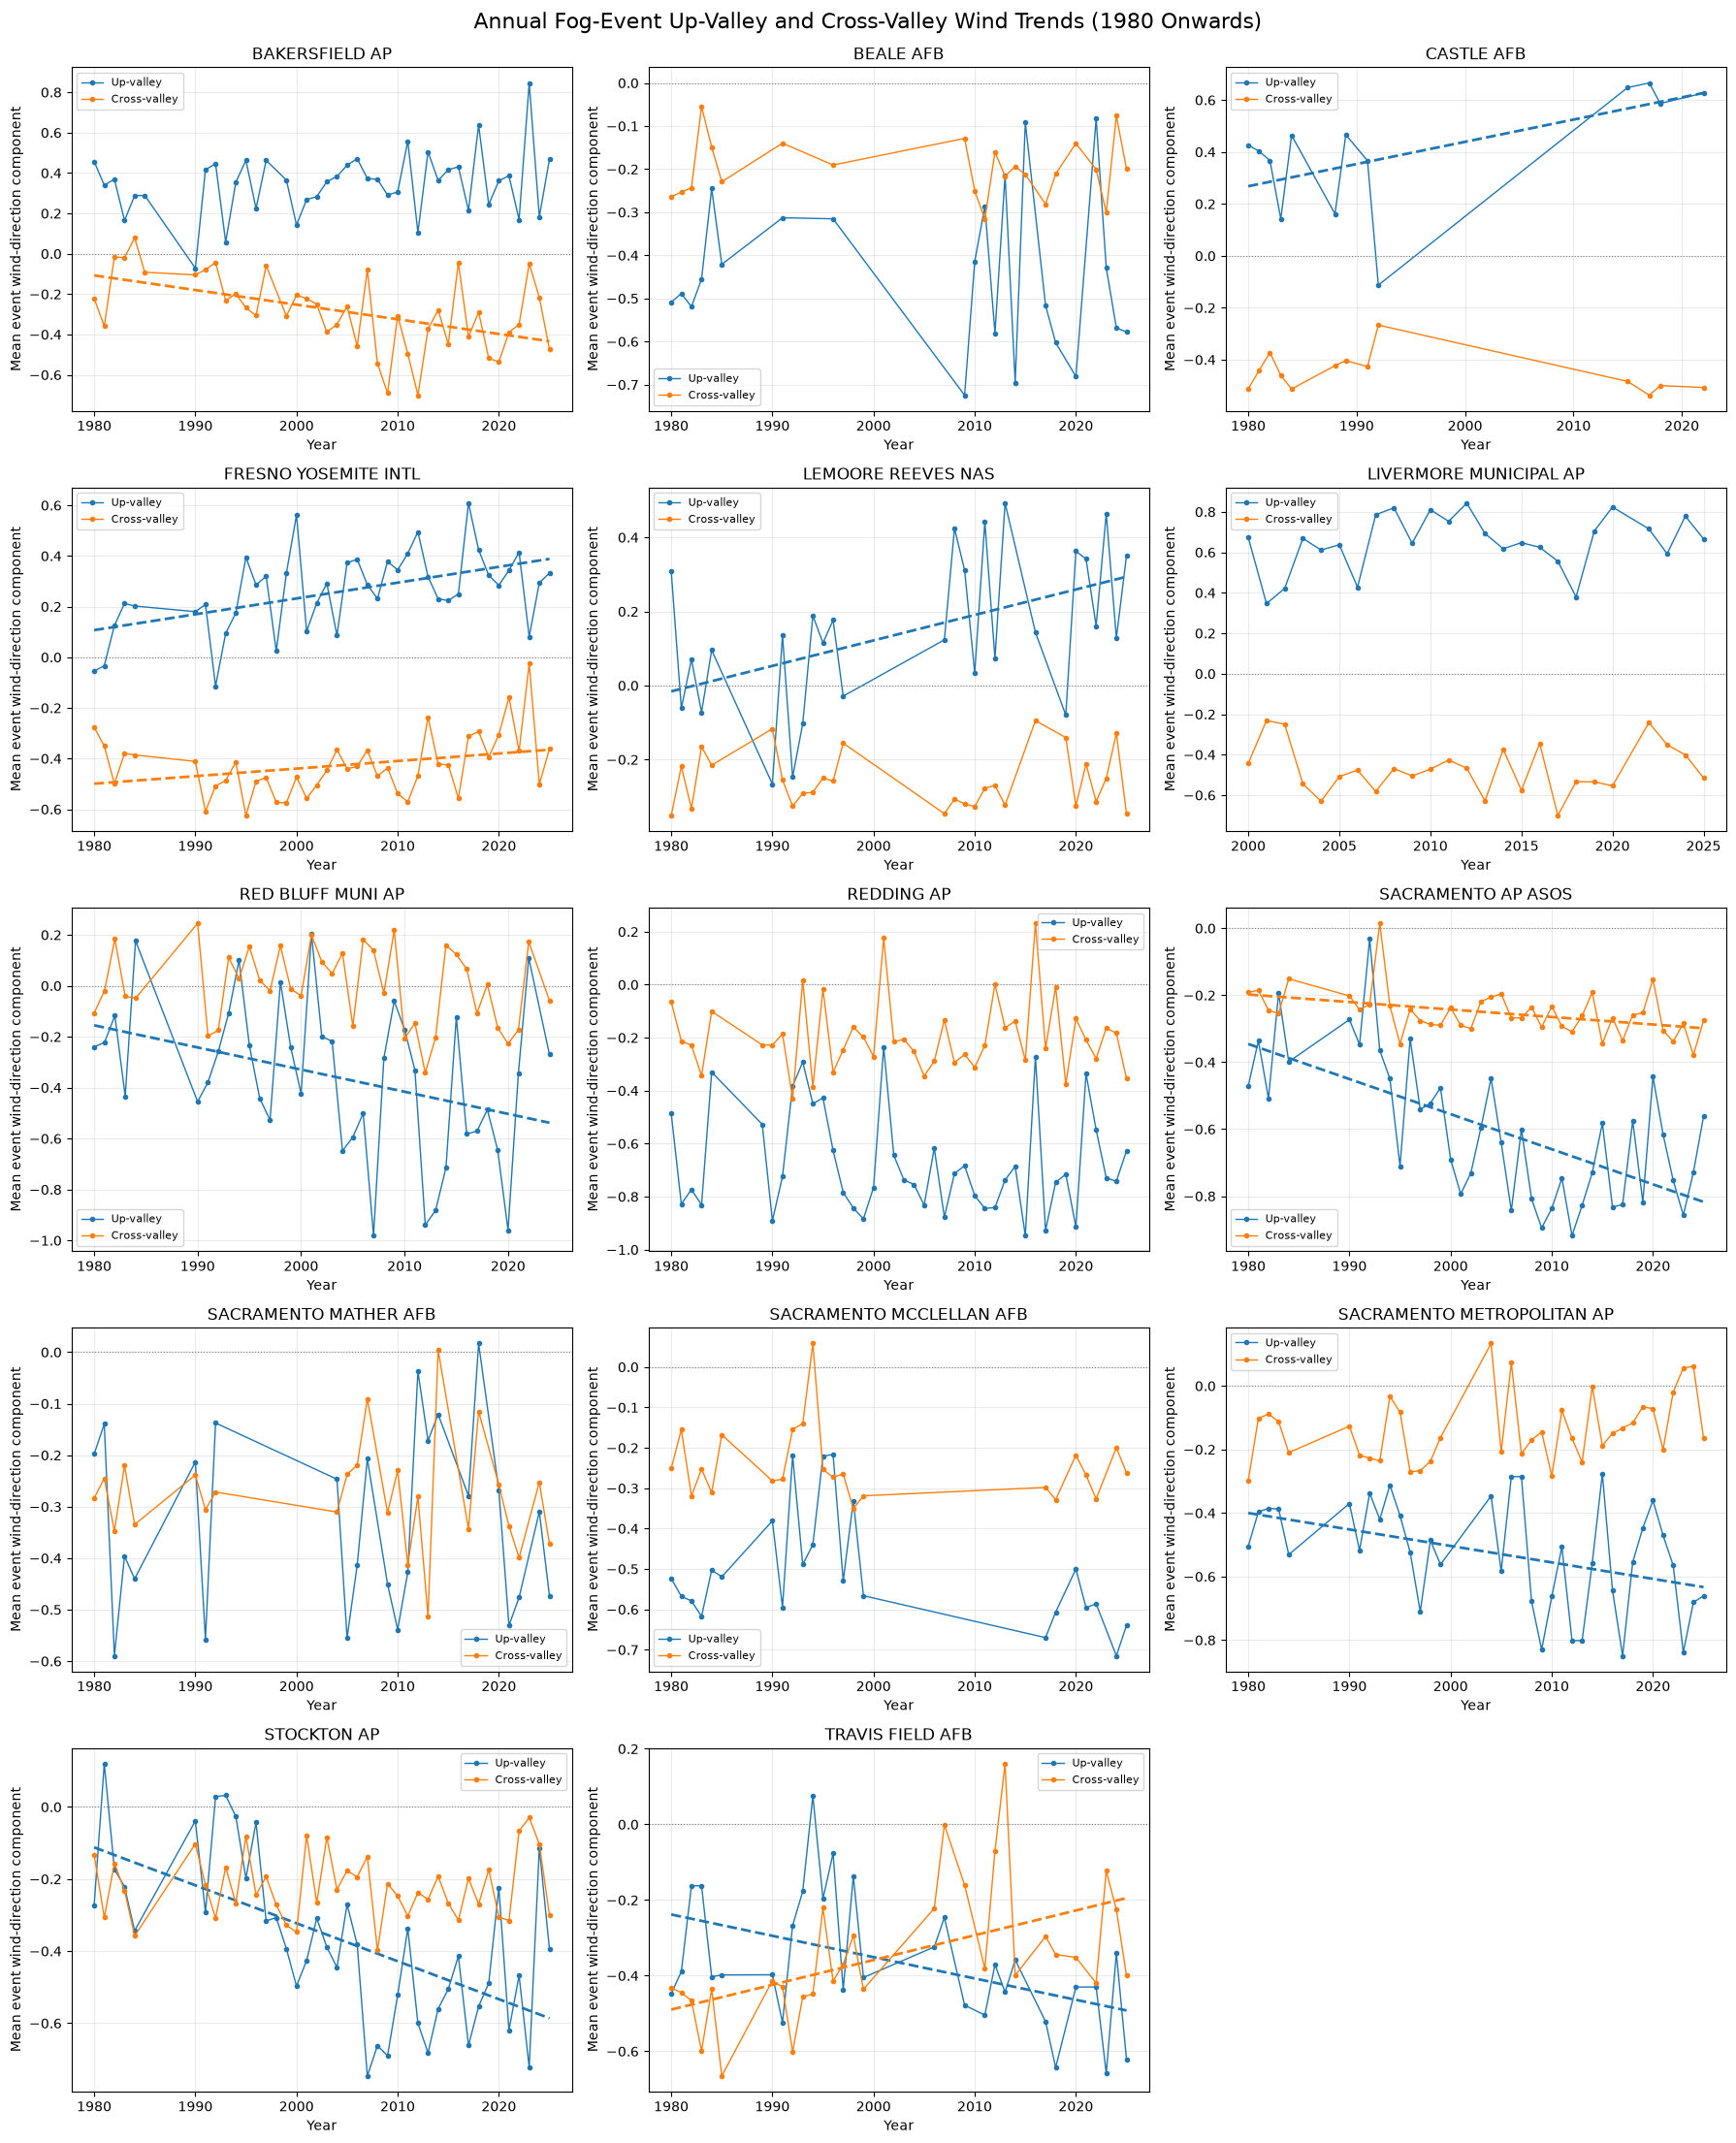

In [21]:
# Annual fog-event wind-direction trends by station.
# Only for years since 1980
# Regression lines are shown only when p < 0.05.

# Use the event observations created in cell 23
event_obs1980 = fog_rows[
    [
        "STATION", "event_number", "year", "HourlyWindDirection",
        "up_valley_direction", "cross_valley_direction"
    ]
].copy()

event_obs1980["HourlyWindDirection"] = pd.to_numeric(
    event_obs1980["HourlyWindDirection"], errors="coerce"
)
event_obs1980 = event_obs1980.dropna(subset=["HourlyWindDirection", "year"])
event_obs1980 = event_obs1980[event_obs1980["year"] >= 1980]

# Calculate circular mean wind direction for each fog event
event_obs1980["wind_rad"] = np.deg2rad(event_obs1980["HourlyWindDirection"])
event_obs1980["u"] = np.cos(event_obs1980["wind_rad"])
event_obs1980["v"] = np.sin(event_obs1980["wind_rad"])

event_wind1980 = (
    event_obs1980
    .groupby(["STATION", "event_number"], as_index=False)
    .agg(
        year=("year", "first"),
        mean_u=("u", "mean"),
        mean_v=("v", "mean"),
        up_valley_direction=("up_valley_direction", "first"),
        cross_valley_direction=("cross_valley_direction", "first"),
        n_observations=("HourlyWindDirection", "size"),
    )
)

event_wind1980["event_mean_direction"] = np.mod(
    np.rad2deg(np.arctan2(event_wind1980["mean_v"], event_wind1980["mean_u"])),
    360
)

# Calculate event-level alignment with each local axis
# multiply by the wind magnitude to get the actual wind component along the up-valley direction
# Here we only consider the angular alignment, not the wind magnitude
event_wind1980["up_valley_component"] = np.cos(
    np.deg2rad(
        event_wind1980["event_mean_direction"]
        - event_wind1980["up_valley_direction"]
    )
)
# ) * event_wind1980["n_observations"]

event_wind1980["cross_valley_component"] = np.cos(
    np.deg2rad(
        event_wind1980["event_mean_direction"]
        - event_wind1980["cross_valley_direction"]
    )
)
# ) * event_wind1980["n_observations"]

# Annual averages of fog-event directional components
annual_event_wind1980 = (
    event_wind1980
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        mean_up_valley_component=("up_valley_component", "mean"),
        mean_cross_valley_component=("cross_valley_component", "mean"),
        n_events=("event_number", "size"),
    )
    .sort_values(["STATION", "year"])
)

# Fit trends for each station and component
event_trend_rows = []

for station, group in annual_event_wind1980.groupby("STATION"):
    for component, column in [
        ("up_valley", "mean_up_valley_component"),
        ("cross_valley", "mean_cross_valley_component"),
    ]:
        data = group[["year", column]].dropna()

        if data["year"].nunique() < 3 or data[column].nunique() < 2:
            continue

        fit = stats.linregress(data["year"], data[column])

        event_trend_rows.append({
            "STATION": station,
            "component": component,
            "start_year": int(data["year"].min()),
            "end_year": int(data["year"].max()),
            "n_years": int(data["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

event_trends1980 = pd.DataFrame(event_trend_rows)
event_trends1980["significant"] = event_trends1980["p_value"] < 0.05

display(event_trends1980.sort_values(["component", "p_value"]))

# Plot both components for every station
stations = sorted(annual_event_wind1980["STATION"].unique())
ncols = 3
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(18, 4.5 * nrows),
    squeeze=False
)
axes = axes.ravel()

for ax, station in zip(axes, stations):
    data = annual_event_wind1980[
        annual_event_wind1980["STATION"] == station
    ].sort_values("year")

    for component, column, color, label in [
        (
            "up_valley",
            "mean_up_valley_component",
            "tab:blue",
            "Up-valley",
        ),
        (
            "cross_valley",
            "mean_cross_valley_component",
            "tab:orange",
            "Cross-valley",
        ),
    ]:
        ax.plot(
            data["year"],
            data[column],
            marker="o",
            markersize=3,
            linewidth=1,
            color=color,
            label=label,
        )

        result = event_trends1980[
            (event_trends1980["STATION"] == station)
            & (event_trends1980["component"] == component)
        ]

        # Add a regression line only for significant trends
        if not result.empty and result.iloc[0]["significant"]:
            result = result.iloc[0]
            fitted = (
                result["slope_per_year"] * data["year"]
                + (
                    data[column].mean()
                    - result["slope_per_year"] * data["year"].mean()
                )
            )

            ax.plot(
                data["year"],
                fitted,
                color=color,
                linestyle="--",
                linewidth=2,
            )

    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean event wind-direction component")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

for ax in axes[len(stations):]:
    ax.remove()

fig.suptitle(
    "Annual Fog-Event Up-Valley and Cross-Valley Wind Trends (1980 Onwards)\n",
    fontsize=16,
)
plt.tight_layout()
plt.show()

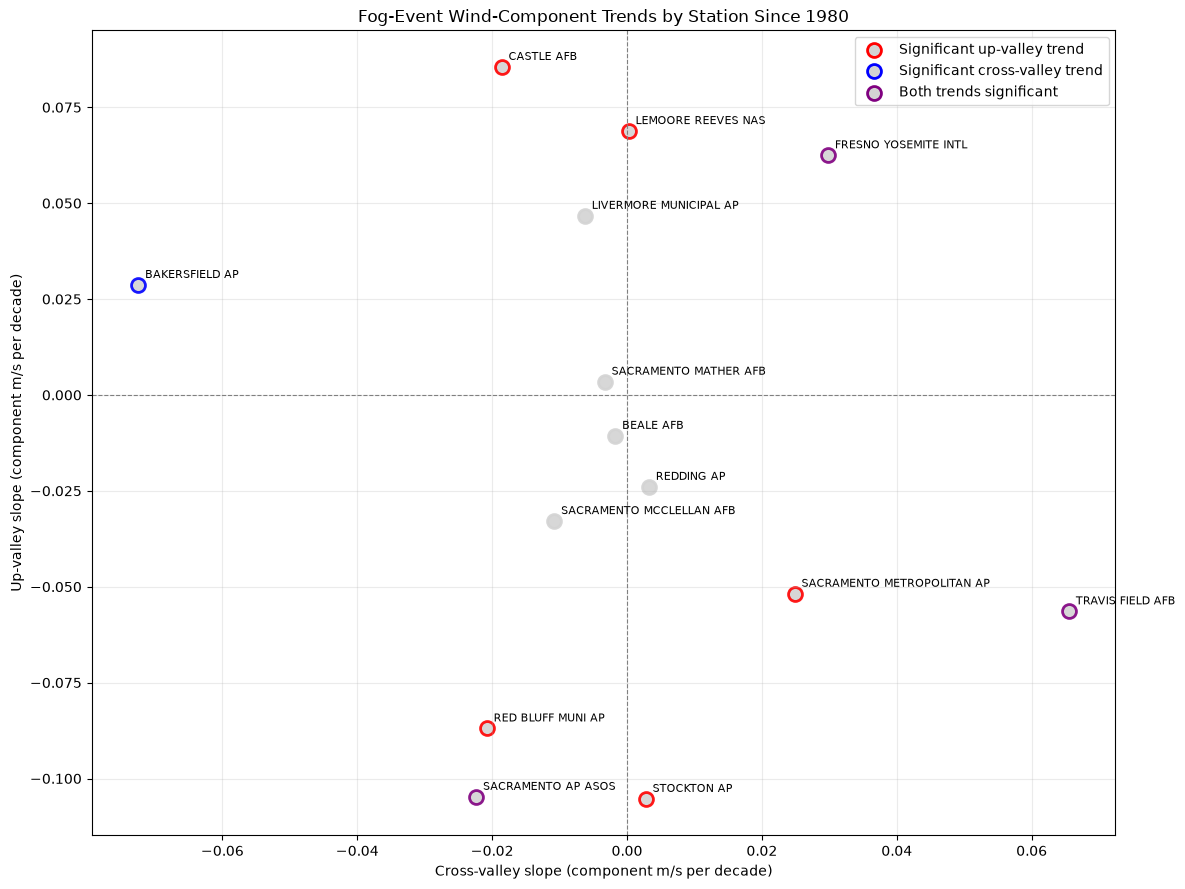

In [22]:
# Plot fog-event trend slopes since 1980
# x-axis = cross-valley slope; y-axis = up-valley slope.
# Red outline = significant up-valley trend
# Blue outline = significant cross-valley trend
# Purple outline = both trends significant

fog_slope_data1980 = (
    event_trends1980
    .pivot(index="STATION", columns="component",
           values=["slope_per_decade", "p_value"])
    .dropna()
)

fog_slope_data1980.columns = [
    f"{metric}_{component}"
    for metric, component in fog_slope_data1980.columns
]

fig, ax = plt.subplots(figsize=(12, 9))

for station, row in fog_slope_data1980.iterrows():
    significant_up1980 = row["p_value_up_valley"] < 0.05
    significant_cross1980 = row["p_value_cross_valley"] < 0.05

    if significant_up1980 and significant_cross1980:
        outline_color = "purple"
    elif significant_up1980:
        outline_color = "red"
    elif significant_cross1980:
        outline_color = "blue"
    else:
        outline_color = "lightgray"

    ax.scatter(
        row["slope_per_decade_cross_valley"],
        row["slope_per_decade_up_valley"],
        s=100,
        facecolor="lightgray",
        edgecolor=outline_color,
        linewidth=2,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["slope_per_decade_cross_valley"],
            row["slope_per_decade_up_valley"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
]:
    ax.scatter(
        [], [], s=100, facecolor="lightgray",
        edgecolor=color, linewidth=2, label=label
    )

ax.set_xlabel("Cross-valley slope (component m/s per decade)")
ax.set_ylabel("Up-valley slope (component m/s per decade)")
ax.set_title("Fog-Event Wind-Component Trends by Station Since 1980")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

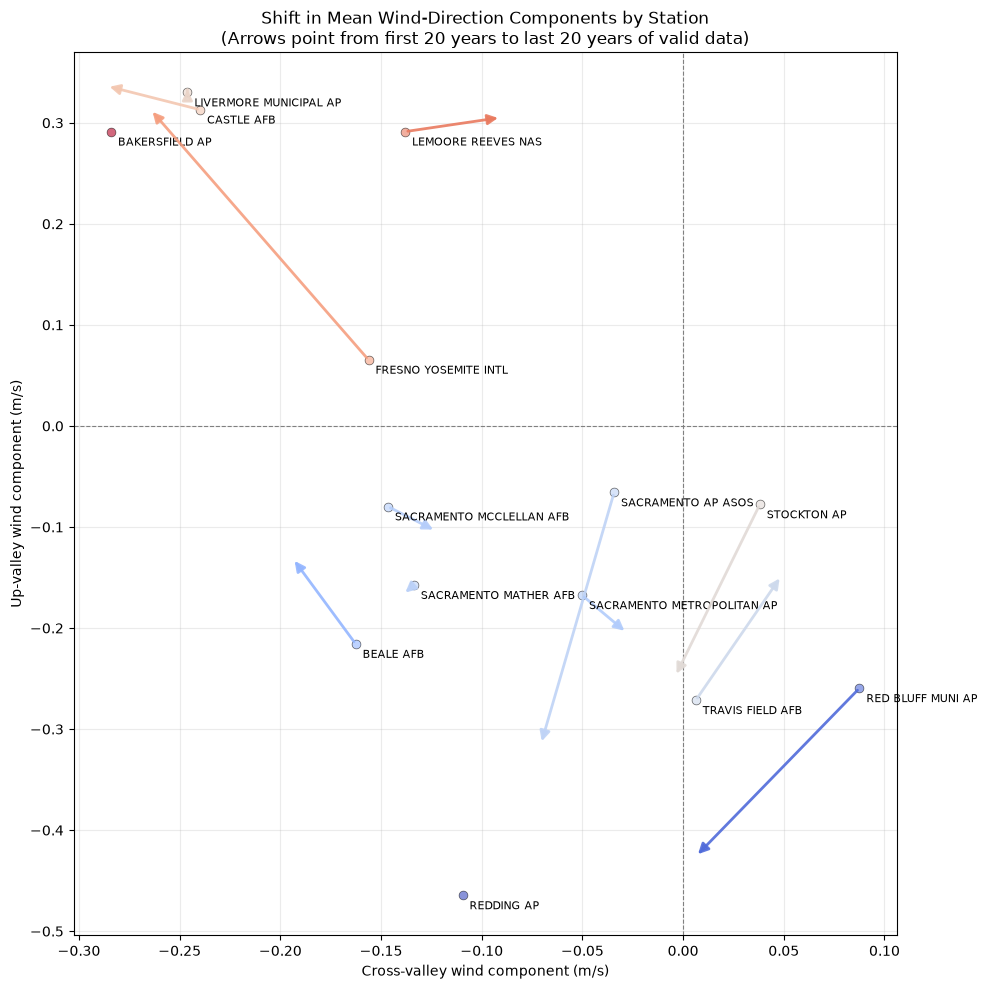

In [23]:
# Wind direction shift plot: arrows from mean (up-valley, cross-valley) components
# during each station's first 20 years of valid data to its last 20 
# show stations with significant trends for all years by outlining them
# make significant up-valley trends outlined in red,
# significant cross-valley trends outlined in blue
# and both outlined in purple

fig, ax = plt.subplots(figsize=(10, 10))

arrow_rows = []

for station, g in annual_avg_wind.groupby("STATION"):
    g = g.dropna(subset=["mean_up_valley_component", "mean_cross_valley_component"])
    g = g.sort_values("year")

    years = g["year"].unique()
    if len(years) < 2:
        continue

    n_years = min(20, len(years))

    first_years = years[:n_years]
    last_years = years[-n_years:]

    first_period = g[g["year"].isin(first_years)]
    last_period = g[g["year"].isin(last_years)]

    start_x = first_period["mean_cross_valley_component"].mean()
    start_y = first_period["mean_up_valley_component"].mean()
    end_x = last_period["mean_cross_valley_component"].mean()
    end_y = last_period["mean_up_valley_component"].mean()

    lat = g["latitude"].iloc[0] if "latitude" in g.columns else np.nan

    arrow_rows.append({
        "STATION": station,
        "start_x": start_x,
        "start_y": start_y,
        "end_x": end_x,
        "end_y": end_y,
        "latitude": lat,
        "first_years_range": (int(first_years.min()), int(first_years.max())),
        "last_years_range": (int(last_years.min()), int(last_years.max())),
    })

arrow_df = pd.DataFrame(arrow_rows)

lat_min_local = arrow_df["latitude"].min()
lat_max_local = arrow_df["latitude"].max()
lat_range_local = lat_max_local - lat_min_local if lat_max_local != lat_min_local else 1

for _, row in arrow_df.iterrows():
    color = plt.cm.coolwarm_r((row["latitude"] - lat_min_local) / lat_range_local)

    ax.annotate(
        "",
        xy=(row["end_x"], row["end_y"]),
        xytext=(row["start_x"], row["start_y"]),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            linewidth=2,
            alpha=0.9,
            mutation_scale=15,
        ),
    )

    # Mark the starting point
    ax.scatter(
        row["start_x"], row["start_y"],
        color=color, marker="o", s=40, alpha=0.6, edgecolors="black", linewidths=0.5
    )

    ax.annotate(
        row["STATION"],
        (row["start_x"], row["start_y"]),
        xytext=(5, -10),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

ax.set_xlabel("Cross-valley wind component (m/s)")
ax.set_ylabel("Up-valley wind component (m/s)")
ax.set_title(
    "Shift in Mean Wind-Direction Components by Station\n"
    "(Arrows point from first 20 years to last 20 years of valid data)"
)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

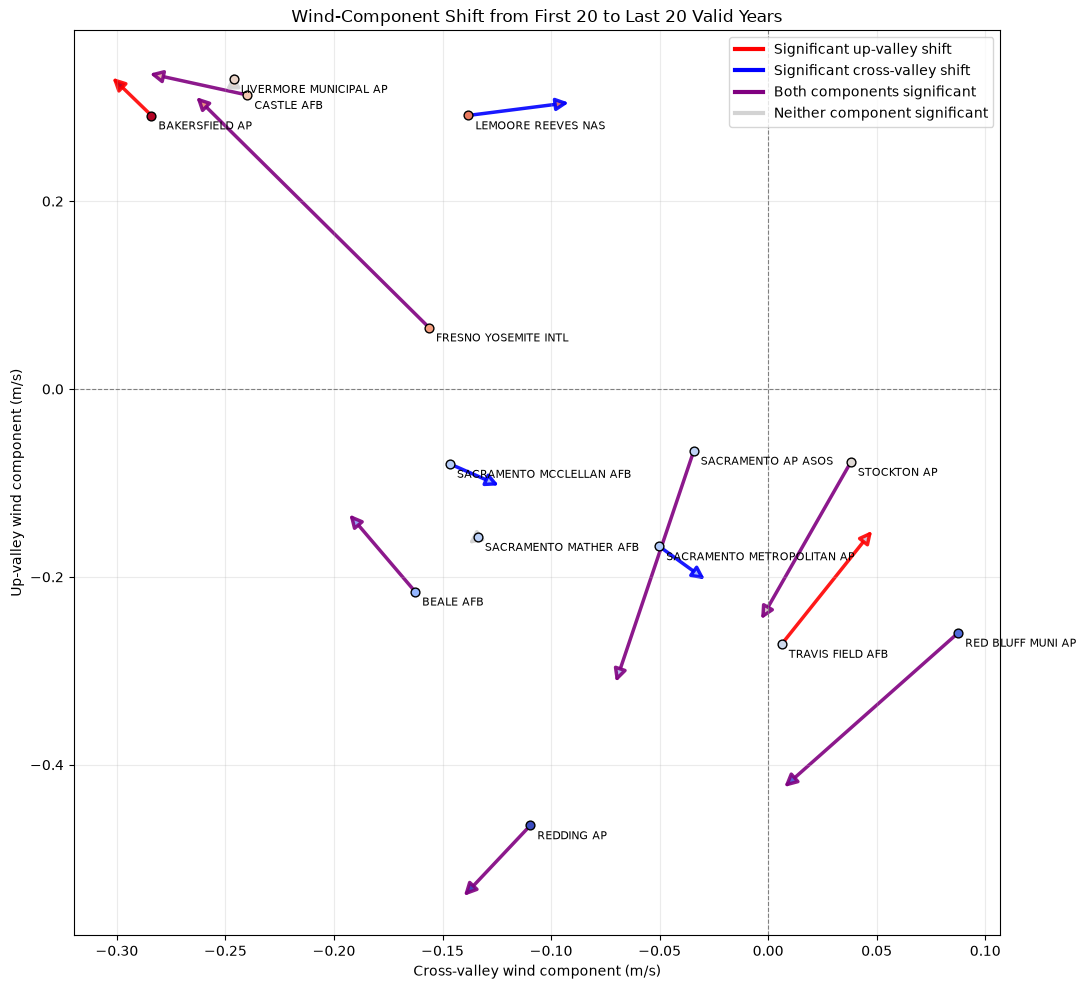

In [24]:
# First and last 20 valid annual observations for each station
# make it so the labels for station arrows do not overlap with the arrows themselves
fig, ax = plt.subplots(figsize=(11, 10))
arrow_rows = []

for station, group in annual_avg_wind.groupby("STATION"):
    group = (
        group.dropna(
            subset=[
                "mean_up_valley_component",
                "mean_cross_valley_component",
                "latitude",
            ]
        )
        .sort_values("year")
    )

    if len(group) < 2:
        continue

    n_periods = min(20, len(group))
    first_period = group.iloc[:n_periods]
    last_period = group.iloc[-n_periods:]

    station_trends = trend_df[trend_df["STATION"] == station]

    sig_up = (
        not station_trends[
            station_trends["component"] == "up_valley"
        ].empty
        and station_trends[
            station_trends["component"] == "up_valley"
        ].iloc[0]["p_value"] < 0.05
    )

    sig_cross = (
        not station_trends[
            station_trends["component"] == "cross_valley"
        ].empty
        and station_trends[
            station_trends["component"] == "cross_valley"
        ].iloc[0]["p_value"] < 0.05
    )

    if sig_up and sig_cross:
        outline_color = "purple"
    elif sig_up:
        outline_color = "red"
    elif sig_cross:
        outline_color = "blue"
    else:
        outline_color = "lightgray"

    arrow_rows.append({
        "STATION": station,
        "start_x": first_period["mean_cross_valley_component"].mean(),
        "start_y": first_period["mean_up_valley_component"].mean(),
        "end_x": last_period["mean_cross_valley_component"].mean(),
        "end_y": last_period["mean_up_valley_component"].mean(),
        "latitude": group["latitude"].iloc[0],
        "outline_color": outline_color,
    })

arrow_df = pd.DataFrame(arrow_rows)

lat_min = arrow_df["latitude"].min()
lat_range = arrow_df["latitude"].max() - lat_min
lat_range = lat_range if lat_range != 0 else 1

for _, row in arrow_df.iterrows():
    fill_color = plt.cm.coolwarm_r(
        (row["latitude"] - lat_min) / lat_range
    )

    ax.add_patch(
        FancyArrowPatch(
            (row["start_x"], row["start_y"]),
            (row["end_x"], row["end_y"]),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=2.5,
            edgecolor=row["outline_color"],
            facecolor=fill_color,
            alpha=0.9,
        )
    )

    ax.scatter(
        row["start_x"],
        row["start_y"],
        color=fill_color,
        edgecolor="black",
        s=40,
        zorder=3,
    )

    ax.annotate(
        row["STATION"],
        (row["start_x"], row["start_y"]),
        xytext=(5, -10),
        textcoords="offset points",
        fontsize=8,
    )

# Legend for significance outlines
for color, label in [
    ("red", "Significant up-valley shift"),
    ("blue", "Significant cross-valley shift"),
    ("purple", "Both components significant"),
    ("lightgray", "Neither component significant"),
]:
    ax.plot([], [], color=color, linewidth=3, label=label)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

ax.set_xlabel("Cross-valley wind component (m/s)")
ax.set_ylabel("Up-valley wind component (m/s)")
ax.set_title(
    "Wind-Component Shift from First 20 to Last 20 Valid Years"
)
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

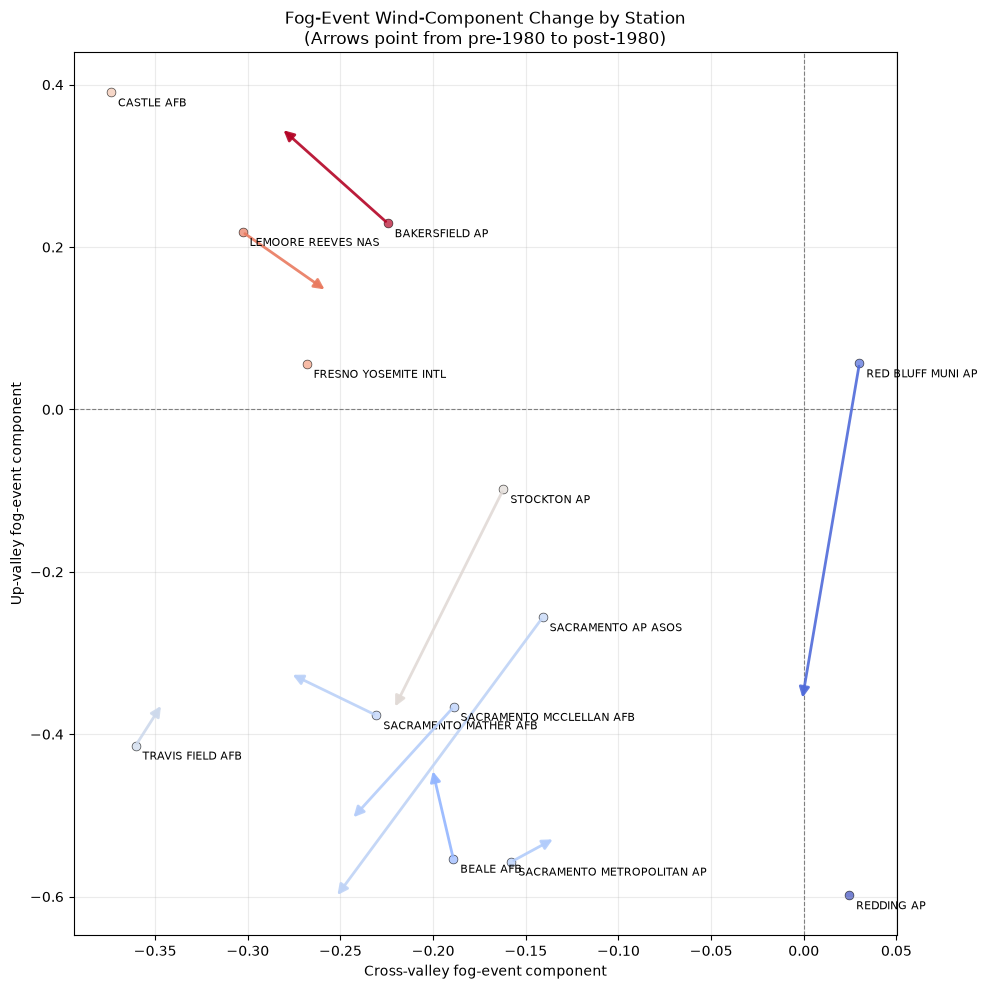

In [25]:
# Fog-event wind-component shifts:
# pre-1980 years compared with post-1980 years (1980 onward)

fog_annual = annual_event_wind.merge(
    station_lat,
    on="STATION",
    how="left"
)

fig, ax = plt.subplots(figsize=(10, 10))
arrow_rows = []

for station, group in fog_annual.groupby("STATION"):
    group = group.dropna(
        subset=[
            "mean_up_valley_component",
            "mean_cross_valley_component",
            "latitude",
        ]
    ).sort_values("year")

    pre_1980 = group[group["year"] < 1980]
    post_1980 = group[group["year"] >= 1980]

    if pre_1980.empty or post_1980.empty:
        continue

    arrow_rows.append({
        "STATION": station,
        "start_x": pre_1980["mean_cross_valley_component"].mean(),
        "start_y": pre_1980["mean_up_valley_component"].mean(),
        "end_x": post_1980["mean_cross_valley_component"].mean(),
        "end_y": post_1980["mean_up_valley_component"].mean(),
        "latitude": group["latitude"].iloc[0],
    })

arrow_df = pd.DataFrame(arrow_rows)

if arrow_df.empty:
    raise ValueError("No stations contain both pre-1980 and post-1980 fog-event data.")

lat_min = arrow_df["latitude"].min()
lat_range = arrow_df["latitude"].max() - lat_min
lat_range = lat_range if lat_range != 0 else 1

for _, row in arrow_df.iterrows():
    color = plt.cm.coolwarm_r(
        (row["latitude"] - lat_min) / lat_range
    )

    ax.annotate(
        "",
        xy=(row["end_x"], row["end_y"]),
        xytext=(row["start_x"], row["start_y"]),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            linewidth=2,
            mutation_scale=15,
            alpha=0.9,
        ),
    )

    ax.scatter(
        row["start_x"],
        row["start_y"],
        color=color,
        marker="o",
        s=40,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.7,
    )

    ax.annotate(
        row["STATION"],
        (row["start_x"], row["start_y"]),
        xytext=(5, -10),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

ax.set_xlabel("Cross-valley fog-event component")
ax.set_ylabel("Up-valley fog-event component")
ax.set_title(
    "Fog-Event Wind-Component Change by Station\n"
    "(Arrows point from pre-1980 to post-1980)"
)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

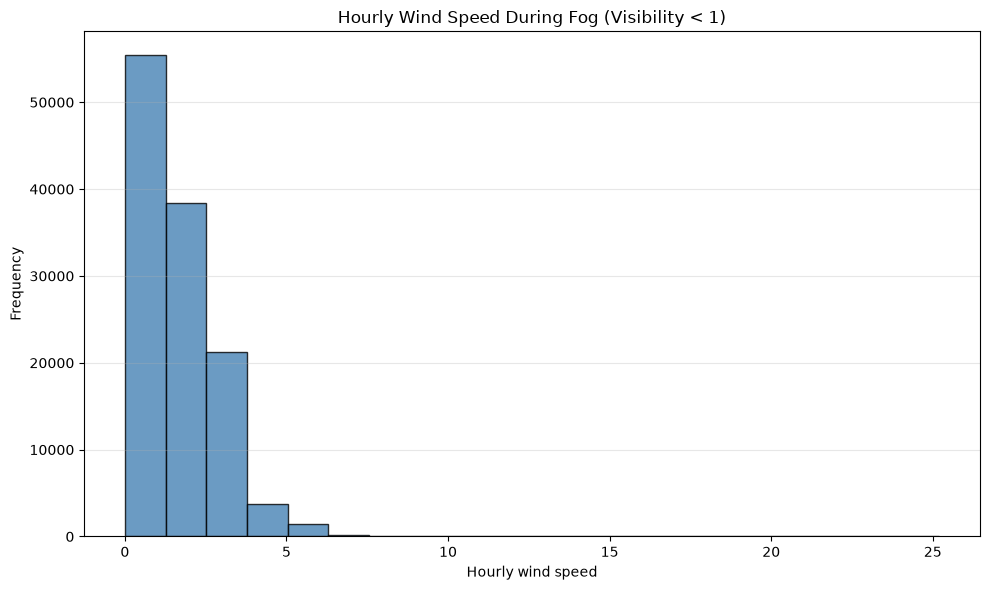

In [26]:
fog_wind_speed = pd.to_numeric(
    CV_filtered_rows.loc[
        CV_filtered_rows["HourlyVisibility"] < 1,
        "HourlyWindSpeed"
    ],
    errors="coerce"
).dropna()

plt.figure(figsize=(10, 6))
plt.hist(
    fog_wind_speed,
    bins=20,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Hourly wind speed")
plt.ylabel("Frequency")
plt.title("Hourly Wind Speed During Fog (Visibility < 1)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

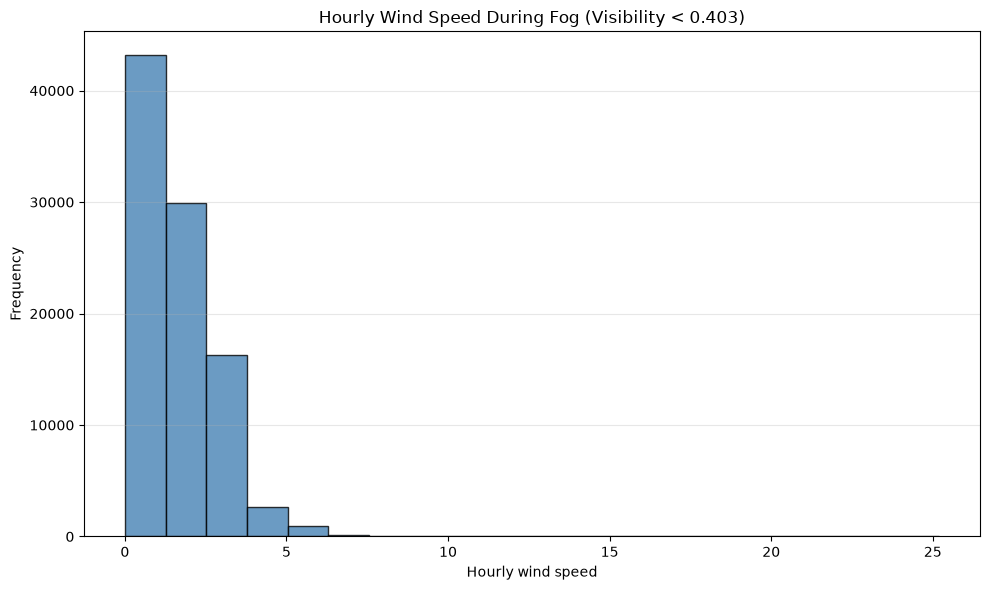

In [27]:
fog_wind_speed = pd.to_numeric(
    CV_filtered_rows.loc[
        CV_filtered_rows["HourlyVisibility"] < 0.403,
        "HourlyWindSpeed"
    ],
    errors="coerce"
).dropna()

plt.figure(figsize=(10, 6))
plt.hist(
    fog_wind_speed,
    bins=20,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Hourly wind speed")
plt.ylabel("Frequency")
plt.title("Hourly Wind Speed During Fog (Visibility < 0.403)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

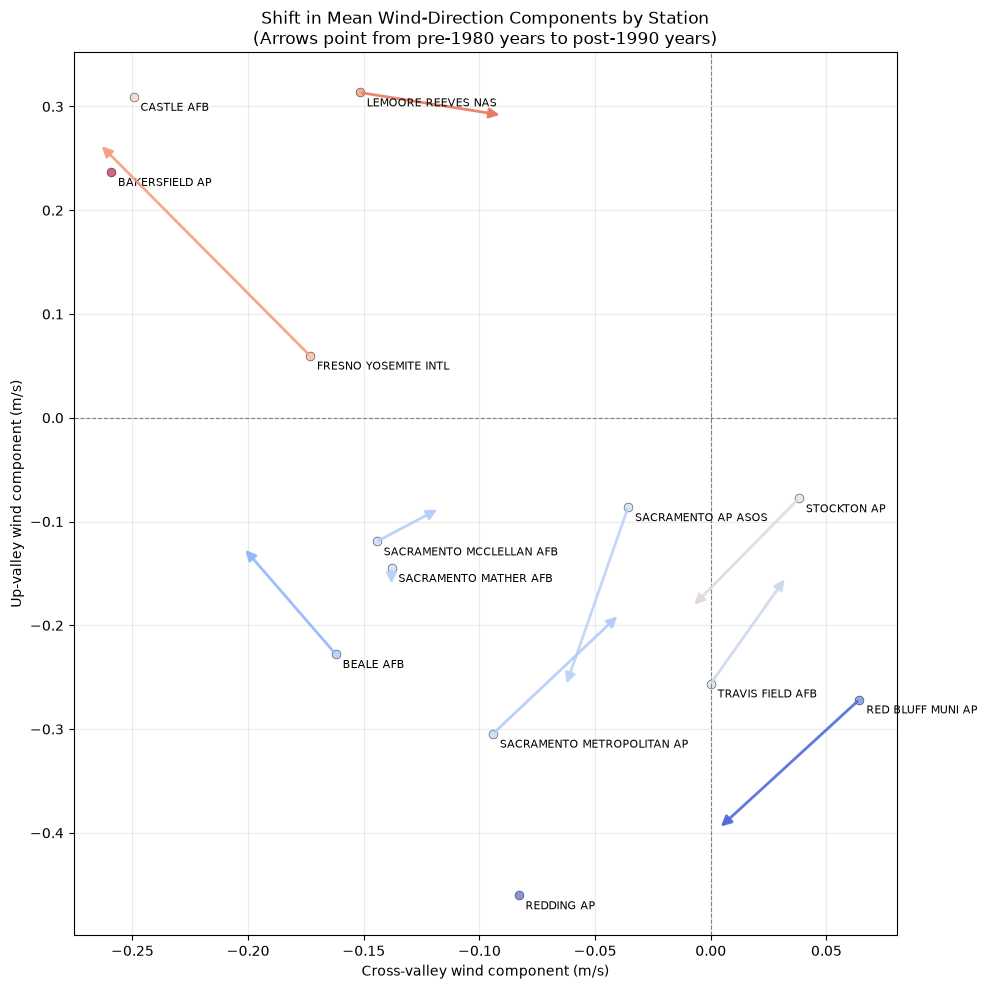

In [28]:
# Wind direction shift plot: arrows from mean (up-valley, cross-valley) components
# use pre-1980 years compared to post-1990 years

fig, ax = plt.subplots(figsize=(10, 10))

arrow_rows = []

for station, g in annual_avg_wind.groupby("STATION"):
    g = g.dropna(subset=["mean_up_valley_component", "mean_cross_valley_component"])
    g = g.sort_values("year")

    years = g["year"].unique()
    if len(years) < 2:
        continue

    first_period = g[g["year"] < 1980]
    last_period = g[g["year"] > 1990]

    if first_period.empty or last_period.empty:
        continue

    start_x = first_period["mean_cross_valley_component"].mean()
    start_y = first_period["mean_up_valley_component"].mean()
    end_x = last_period["mean_cross_valley_component"].mean()
    end_y = last_period["mean_up_valley_component"].mean()

    lat = g["latitude"].iloc[0] if "latitude" in g.columns else np.nan

    arrow_rows.append({
        "STATION": station,
        "start_x": start_x,
        "start_y": start_y,
        "end_x": end_x,
        "end_y": end_y,
        "latitude": lat,
        "first_years_range": (int(first_period["year"].min()), int(first_period["year"].max())),
        "last_years_range": (int(last_period["year"].min()), int(last_period["year"].max())),
    })

arrow_df = pd.DataFrame(arrow_rows)

lat_min_local = arrow_df["latitude"].min()
lat_max_local = arrow_df["latitude"].max()
lat_range_local = lat_max_local - lat_min_local if lat_max_local != lat_min_local else 1

for _, row in arrow_df.iterrows():
    color = plt.cm.coolwarm_r((row["latitude"] - lat_min_local) / lat_range_local)

    ax.annotate(
        "",
        xy=(row["end_x"], row["end_y"]),
        xytext=(row["start_x"], row["start_y"]),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            linewidth=2,
            alpha=0.9,
            mutation_scale=15,
        ),
    )

    # Mark the starting point
    ax.scatter(
        row["start_x"], row["start_y"],
        color=color, marker="o", s=40, alpha=0.6, edgecolors="black", linewidths=0.5
    )

    ax.annotate(
        row["STATION"],
        (row["start_x"], row["start_y"]),
        xytext=(5, -10),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

ax.set_xlabel("Cross-valley wind component (m/s)")
ax.set_ylabel("Up-valley wind component (m/s)")
ax.set_title(
    "Shift in Mean Wind-Direction Components by Station\n"
    "(Arrows point from pre-1980 years to post-1990 years)"
)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

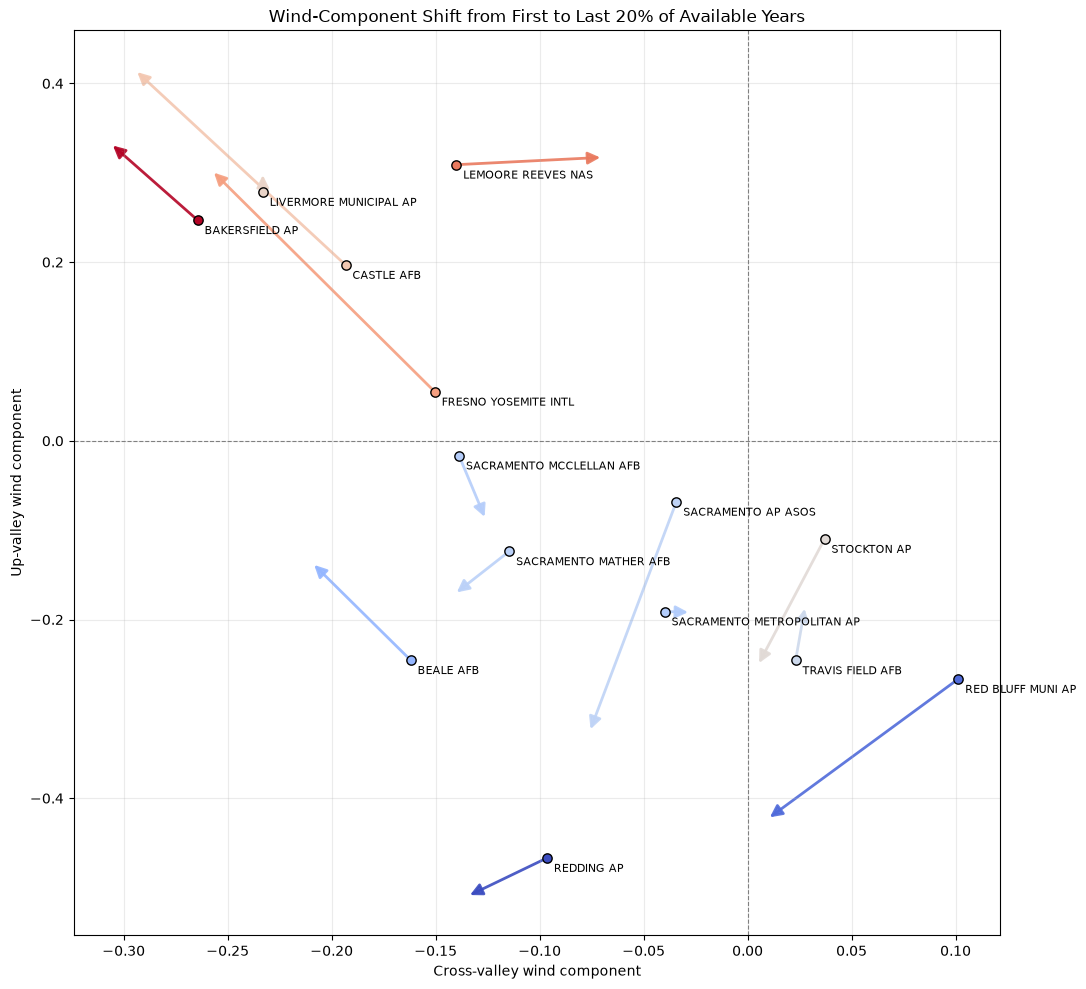

,STATION,start_x,start_y,end_x,end_y,latitude,first_years,last_years
0,BAKERSFIELD AP,-0.264439,0.246961,-0.306170,0.332524,35.43440,1932–1954,2009–2025
1,BEALE AFB,-0.162014,-0.245495,-0.209331,-0.136715,39.13333,1960–1967,2015–2025
2,CASTLE AFB,-0.193323,0.196763,-0.294416,0.414774,37.38333,1942–1952,1984–2022
3,FRESNO YOSEMITE INTL,-0.150423,0.054912,-0.257519,0.302305,36.78000,1942–1961,2011–2025
4,LEMOORE REEVES NAS,-0.140098,0.309042,-0.069514,0.317303,36.33333,1962–1970,2013–2025
5,LIVERMORE MUNICIPAL AP,-0.233119,0.278512,-0.233088,0.300533,37.69270,2000–2004,2020–2025
6,RED BLUFF MUNI AP,0.101262,-0.266594,0.009601,-0.423222,40.15190,1946–1959,2010–2024
7,REDDING AP,-0.096482,-0.466922,-0.134707,-0.509763,40.51750,1977–1990,2017–2025
8,SACRAMENTO AP ASOS,-0.034268,-0.068283,-0.075993,-0.325685,38.50690,1932–1955,2009–2025
9,SACRAMENTO MATHER AFB,-0.114619,-0.123677,-0.140889,-0.171551,38.56667,1942–1954,2010–2025


In [29]:
# Wind-component shift using the first and last 20% of valid annual data
# for each station across all available years.

fig, ax = plt.subplots(figsize=(11, 10))
arrow_rows = []

for station, group in annual_avg_wind.groupby("STATION"):
    group = (
        group[
            [
                "STATION",
                "year",
                "mean_up_valley_component",
                "mean_cross_valley_component",
                "latitude",
            ]
        ]
        .dropna()
        .sort_values("year")
    )

    if group.empty:
        continue

    n_periods = max(1, int(np.ceil(len(group) * 0.20)))

    first_period = group.iloc[:n_periods]
    last_period = group.iloc[-n_periods:]

    arrow_rows.append({
        "STATION": station,
        "start_x": first_period["mean_cross_valley_component"].mean(),
        "start_y": first_period["mean_up_valley_component"].mean(),
        "end_x": last_period["mean_cross_valley_component"].mean(),
        "end_y": last_period["mean_up_valley_component"].mean(),
        "latitude": group["latitude"].iloc[0],
        "first_years": f"{first_period['year'].min()}–{first_period['year'].max()}",
        "last_years": f"{last_period['year'].min()}–{last_period['year'].max()}",
    })

arrow_df_20pct = pd.DataFrame(arrow_rows)

lat_min = arrow_df_20pct["latitude"].min()
lat_range = arrow_df_20pct["latitude"].max() - lat_min
lat_range = lat_range if lat_range != 0 else 1

for _, row in arrow_df_20pct.iterrows():
    color = plt.cm.coolwarm_r(
        (row["latitude"] - lat_min) / lat_range
    )

    ax.add_patch(
        FancyArrowPatch(
            (row["start_x"], row["start_y"]),
            (row["end_x"], row["end_y"]),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=2,
            color=color,
            alpha=0.9,
        )
    )

    ax.scatter(
        row["start_x"],
        row["start_y"],
        color=color,
        edgecolor="black",
        s=45,
        zorder=3,
    )

    ax.annotate(
        row["STATION"],
        (row["start_x"], row["start_y"]),
        xytext=(5, -10),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

ax.set_xlabel("Cross-valley wind component")
ax.set_ylabel("Up-valley wind component")
ax.set_title(
    "Wind-Component Shift from First to Last 20% of Available Years"
)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

display(arrow_df_20pct)

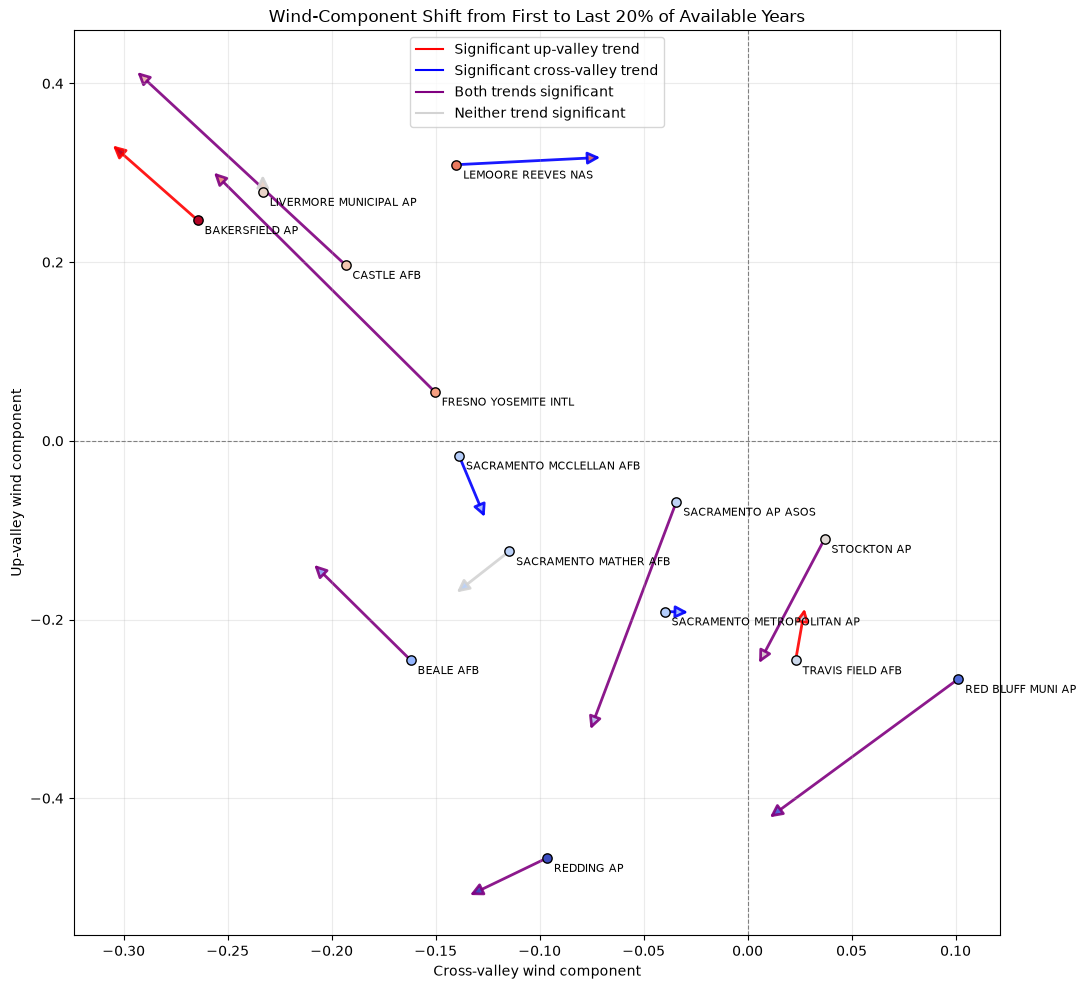

,STATION,start_x,start_y,end_x,end_y,latitude,outline_color
0,BAKERSFIELD AP,-0.264439,0.246961,-0.306170,0.332524,35.43440,red
1,BEALE AFB,-0.162014,-0.245495,-0.209331,-0.136715,39.13333,purple
2,CASTLE AFB,-0.193323,0.196763,-0.294416,0.414774,37.38333,purple
3,FRESNO YOSEMITE INTL,-0.150423,0.054912,-0.257519,0.302305,36.78000,purple
4,LEMOORE REEVES NAS,-0.140098,0.309042,-0.069514,0.317303,36.33333,blue
5,LIVERMORE MUNICIPAL AP,-0.233119,0.278512,-0.233088,0.300533,37.69270,lightgray
6,RED BLUFF MUNI AP,0.101262,-0.266594,0.009601,-0.423222,40.15190,purple
7,REDDING AP,-0.096482,-0.466922,-0.134707,-0.509763,40.51750,purple
8,SACRAMENTO AP ASOS,-0.034268,-0.068283,-0.075993,-0.325685,38.50690,purple
9,SACRAMENTO MATHER AFB,-0.114619,-0.123677,-0.140889,-0.171551,38.56667,lightgray


In [30]:
# Wind-component shifts using the first and last 20% of valid annual data.
# Outline colors indicate significant trends:
# red = significant up-valley trend
# blue = significant cross-valley trend
# purple = both significant

# make the arrows outlined in colors, not the datapoints

fig, ax = plt.subplots(figsize=(11, 10))
arrow_rows_20pct = []

for station, group in annual_avg_wind.groupby("STATION"):
    group = (
        group[
            [
                "STATION",
                "year",
                "mean_up_valley_component",
                "mean_cross_valley_component",
                "latitude",
            ]
        ]
        .dropna()
        .sort_values("year")
    )

    if len(group) < 2:
        continue

    n_periods = max(1, int(np.ceil(len(group) * 0.20)))
    first_period = group.iloc[:n_periods]
    last_period = group.iloc[-n_periods:]

    station_trends = trend_df[trend_df["STATION"] == station]

    up_trend = station_trends[
        station_trends["component"] == "up_valley"
    ]
    cross_trend = station_trends[
        station_trends["component"] == "cross_valley"
    ]

    sig_up = not up_trend.empty and up_trend.iloc[0]["p_value"] < 0.05
    sig_cross = not cross_trend.empty and cross_trend.iloc[0]["p_value"] < 0.05

    if sig_up and sig_cross:
        outline_color = "purple"
    elif sig_up:
        outline_color = "red"
    elif sig_cross:
        outline_color = "blue"
    else:
        outline_color = "lightgray"

    arrow_rows_20pct.append({
        "STATION": station,
        "start_x": first_period["mean_cross_valley_component"].mean(),
        "start_y": first_period["mean_up_valley_component"].mean(),
        "end_x": last_period["mean_cross_valley_component"].mean(),
        "end_y": last_period["mean_up_valley_component"].mean(),
        "latitude": group["latitude"].iloc[0],
        "outline_color": outline_color,
    })

arrow_df_20pct_sig = pd.DataFrame(arrow_rows_20pct)

lat_min = arrow_df_20pct_sig["latitude"].min()
lat_range = (
    arrow_df_20pct_sig["latitude"].max() - lat_min
    if len(arrow_df_20pct_sig) > 1
    else 1
)

for _, row in arrow_df_20pct_sig.iterrows():
    latitude_color = plt.cm.coolwarm_r(
        (row["latitude"] - lat_min) / lat_range
    )

    ax.add_patch(
        FancyArrowPatch(
            (row["start_x"], row["start_y"]),
            (row["end_x"], row["end_y"]),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=2,
            edgecolor=row["outline_color"],
            facecolor=latitude_color,
            alpha=0.9,
        )
    )

    # Starting point
    ax.scatter(
        row["start_x"],
        row["start_y"],
        color=latitude_color,
        edgecolor="black",
        s=45,
        zorder=3,
    )

    ax.annotate(
        row["STATION"],
        (row["start_x"], row["start_y"]),
        xytext=(5, -10),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

for color, label in [
    ("red", "Significant up-valley trend"),
    ("blue", "Significant cross-valley trend"),
    ("purple", "Both trends significant"),
    ("lightgray", "Neither trend significant"),
]:
    ax.plot([], [], color=color, label=label)

ax.set_xlabel("Cross-valley wind component")
ax.set_ylabel("Up-valley wind component")
ax.set_title(
    "Wind-Component Shift from First to Last 20% of Available Years"
)
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

display(arrow_df_20pct_sig)